<a href="https://colab.research.google.com/github/benstaf/ycbench/blob/main/YC_W26_Google_Mentions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ── Color palette ─────────────────────────────────────────────────────────────
COL_MENTIONS_DEMO     = "#185FA5"  # blue-600  — pre-demo-day google mentions (ground truth)
COL_MENTIONS_BASELINE = "#85B7EB"  # blue-200  — pre-application google mentions (baseline predictor)
COL_TRACTION          = "#7F77DD"  # purple-400 — velocity / VC-weighted score
COL_TOP               = "#1D9E75"  # teal-400  — top 10% cohort / correctly predicted
COL_REST              = "#888780"  # gray-400  — bottom 90% / neutral bars
COL_MISSED            = "#BA7517"  # amber-400 — missed by baseline
COL_CUTOFF            = "#5F5E5A"  # gray-600  — reference lines, cutoff markers

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

# 1. Load the raw data
raw_data = """trycardinal.ai: 6
try.wideframe.com: 40
martini.film: 0
condor.energy: 0
resonate.audio: 0
shofo.ai: 103
wayco.ai: 131
unifold.io: 44
carrotlabs.ai: 28
aurorincad.com: 0
daivin.tech: 42
grazemate.com: 67
origami-robotics.com: 77
librarlabs.com: 41
therubric.ai: 9
zymbly.com: 8
ritivel.com: 25
usepolymorph.com: 10
pollinate.tech: 25
spotpay.ai: 564
voygr.tech: 34
mochacare.com: 10
tryvela.ai: 79
veriad.com: 9
talkingcomputers.ai: 9
copperlane.ai: 113
runcanary.ai: 31
usegrade.com: 47
silahq.com: 61
trymaven.com: 25
usemoda.ai: 5
thetokencompany.com: 115
beesafe.ai: 209
fed10.ai: 65
squid.energy: 0
usecrow.ai: 53
scoutout.ai: 43
bookoapp.com: 97
corelayer.com: 10
general.legal: 0
fort.cx: 222
getbalance.ai: 27
chasi.co: 57
tryremy.ai: 8
buildwithglue.com: 2
o11.ai: 1140
doomersion.com: 6
sequencemkts.com: 77
dittobio.com: 40
servo7.com: 7
arzule.com: 39
voxelenergy.com: 41
polymathlabs.ai: 38
bubblelab.ai: 483
heypocket.com: 755
byteport.io: 7
constellationspace.ai: 3
mendral.com: 55
axionorbital.space: 309
oximy.com: 64
caretta.so: 144
samora.ai: 171
humanarchive.ai: 156
forum.market: 0
sitefire.ai: 92
tryrobby.com: 6
ressl.ai: 500
emdash.sh: 43
congruent.io: 130
usereframe.ai: 10
valence.trade: 57
approxima.ai: 4
traverse.so: 0
revion.inc: 8
maywoodai.com: 30
fenrock.ai: 241
endclose.com: 5
usechamber.io: 99
patientdesk.ai: 899
visiblsemi.com: 235
syntheticsciences.ai: 117
seeing-systems.com: 10
jinba.io: 310
usecardboard.com: 165
pranadoc.com: 60
rhizomeai.com: 10
paxhistoria.co: 10500
hex.co: 0
trylaurence.com: 90
terminaluse.com: 76
overshoot.ai: 230
caj.al: 0
proximitty.ai: 39
stilta.com: 39
unisson.ai: 10
incidentfox.ai: 154
compresr.ai: 241
opalitehealth.com: 6
confluence.sh: 175
mangomedical.io: 3
paysponge.com: 58
terranox.ai: 158
ventura.ai: 0
orthogonal.com: 150
perfectly.so: 0
getfern.ai: 5
sparkles.dev: 221
eigenpal.com: 74
usesalus.ai: 10
arcline-ai.com: 40
ramain.ai: 97
milliray.com: 1
beyondreachlabs.com: 8
tryoctapulse.com: 10
codewisp.ai: 257
ashr.io: 130
aemon.ai: 95
luel.ai: 591
schedulingwiz.com: 3
robodock.tech: 25
skillsync.wiki: 77
mousecat.ai: 58
zatanna.ai: 154
autositu.com: 10
verdexai.com: 9
cumuluslabs.io: 63
tepali.com: 5
palus.finance: 278
21st.dev: 4260
avoice.co: 36
kytentech.com: 28
zerosettle.io: 76
usecarson.com: 39
openspec.dev: 239
pirislabs.io: 50
celltype.com: 41
trainburt.com: 25
envariant.ai: 6
runcascade.com: 10
beaconhealth.ai: 154
strandai.com: 32
tryclam.com: 29
protent.ai: 69
cofia.ai: 122
getnoetic.ai: 26
legalos.ai: 97
sentrial.com: 90
10xscience.com: 10
rev1.so: 84
shortkit.dev: 39
tryasimov.ai: 26
lexius.ai: 84
axisanalysis.com: 115
sonarly.com: 26
docurahealth.com: 8
lance.live: 0
runanywhere.ai: 971
lucenthq.com: 66
rumacare.com: 37
klausai.com: 62
usekita.com: 92
syntropy.io: 10
onerobot.io: 10
didit.me: 4350
pantainsure.com: 40
payna.com: 8
origin.bio: 0
hlaboratories.com: 10
helloeos.ai: 4
valgo.ai: 112
arcprize.org: 860
corvera.ai: 64
fullseam.com: 10
catchbackcards.com: 295
mantisbiotech.com: 7
haladir.com: 41
claimglide.com: 2
inviscidai.com: 25
ndea.com: 168
crosslayerlabs.com: 26
voltairlabs.com: 47
vectorlegal.com: 40
generalastro.com: 5
oxus-ai.com: 10
runcaptain.com: 30
agenticfabriq.com: 6
travoai.com: 4
velum-labs.com: 4
alt-x.co: 4
buttoncomputer.com: 41
pollen.cx: 9
autumnai.com: 6
overdrive.health: 179
returnsignals.com: 50
gru.space: 13300
usebidflow.com: 7
menza.ai: 115
tryq2q.com: 78"""

# 2. Parse into a DataFrame
lines = [line.split(": ") for line in raw_data.strip().split("\n")]
df = pd.DataFrame(lines, columns=["domain", "google_mentions"])
df["google_mentions"] = pd.to_numeric(df["google_mentions"])

# 3. Clean and sort (remove zeros for log-scale plotting)
df = df[df["google_mentions"] > 0]
df = df.sort_values(by="google_mentions", ascending=False).reset_index(drop=True)

print(f"Loaded {len(df)} active startup domains.")
df.head()

Loaded 184 active startup domains.


,domain,google_mentions
0,gru.space,13300
1,paxhistoria.co,10500
2,didit.me,4350
3,21st.dev,4260
4,o11.ai,1140


Total active domains: 184
Top 10% contains: 20 domains
These 20 domains represent 81.7% of all Google mentions in the dataset



,rank,domain,google_mentions,pct_of_total
0,1,gru.space,13300,26.4
1,2,paxhistoria.co,10500,20.9
2,3,didit.me,4350,8.6
3,4,21st.dev,4260,8.5
4,5,o11.ai,1140,2.3
5,6,runanywhere.ai,971,1.9
6,7,patientdesk.ai,899,1.8
7,8,arcprize.org,860,1.7
8,9,heypocket.com,755,1.5
9,10,luel.ai,591,1.2


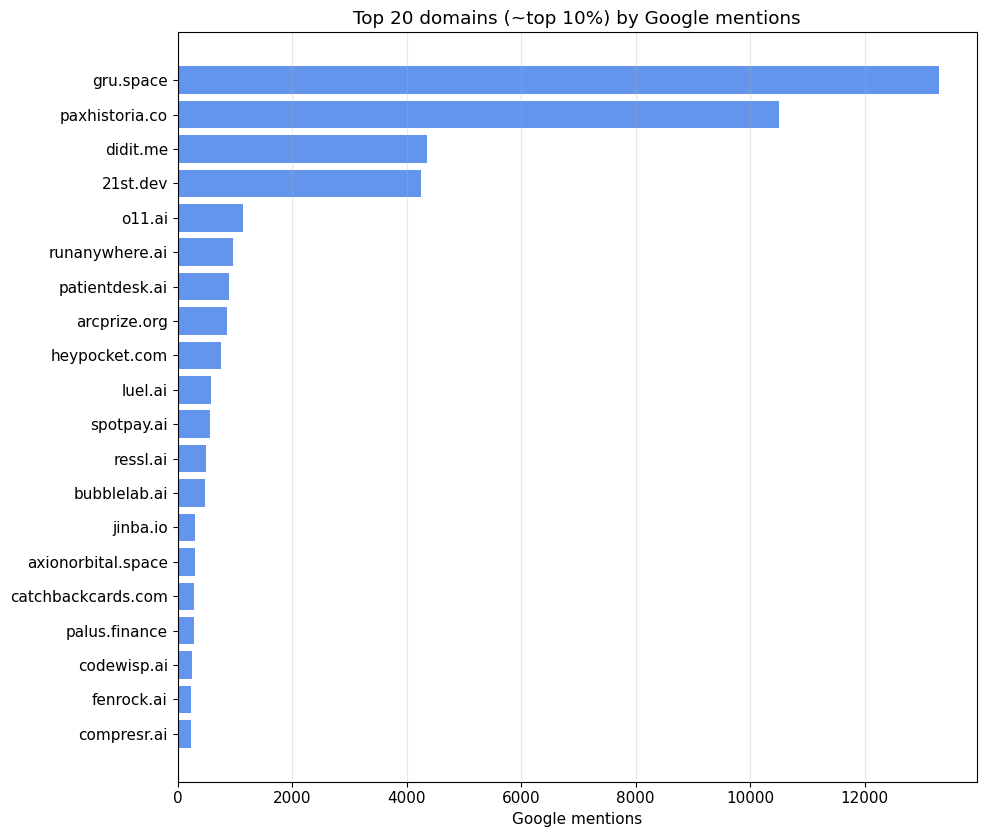

In [ ]:

# ────────────────────────────────────────────────
#          Top 10% of domains by Google mentions
# ────────────────────────────────────────────────

# Number of domains in top 10%
n_total = len(df)
#n_top = max(1, round(n_total * 0.10))   # at least 1, rounded to nearest integer
n_top = 20 # User specified to take top 19 domains

# Take top 10%
top_10pct = df.head(n_top).copy()

# Add rank column (1-based)
top_10pct['rank'] = top_10pct.index + 1

# Optional: add percentage of total mentions
total_mentions = df['google_mentions'].sum()
top_10pct['pct_of_total'] = (top_10pct['google_mentions'] / total_mentions * 100).round(1)

print(f"Total active domains: {n_total}")
print(f"Top 10% contains: {n_top} domains")
print(f"These {n_top} domains represent {top_10pct['google_mentions'].sum() / total_mentions * 100:.1f}% "
      f"of all Google mentions in the dataset\n")

# Show nicely formatted table
display(top_10pct[['rank', 'domain', 'google_mentions', 'pct_of_total']])

# ── Optional quick bar chart of top 10% ───────────────
if n_top <= 40:  # avoid horrible plot when there are too many
    plt.figure(figsize=(10, len(top_10pct) * 0.35 + 1.5))
    plt.barh(top_10pct['domain'], top_10pct['google_mentions'], color='cornflowerblue')
    plt.gca().invert_yaxis()
    plt.title(f'Top {n_top} domains (~top 10%) by Google mentions')
    plt.xlabel('Google mentions')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("→ Too many domains in top 10% to plot meaningfully.")

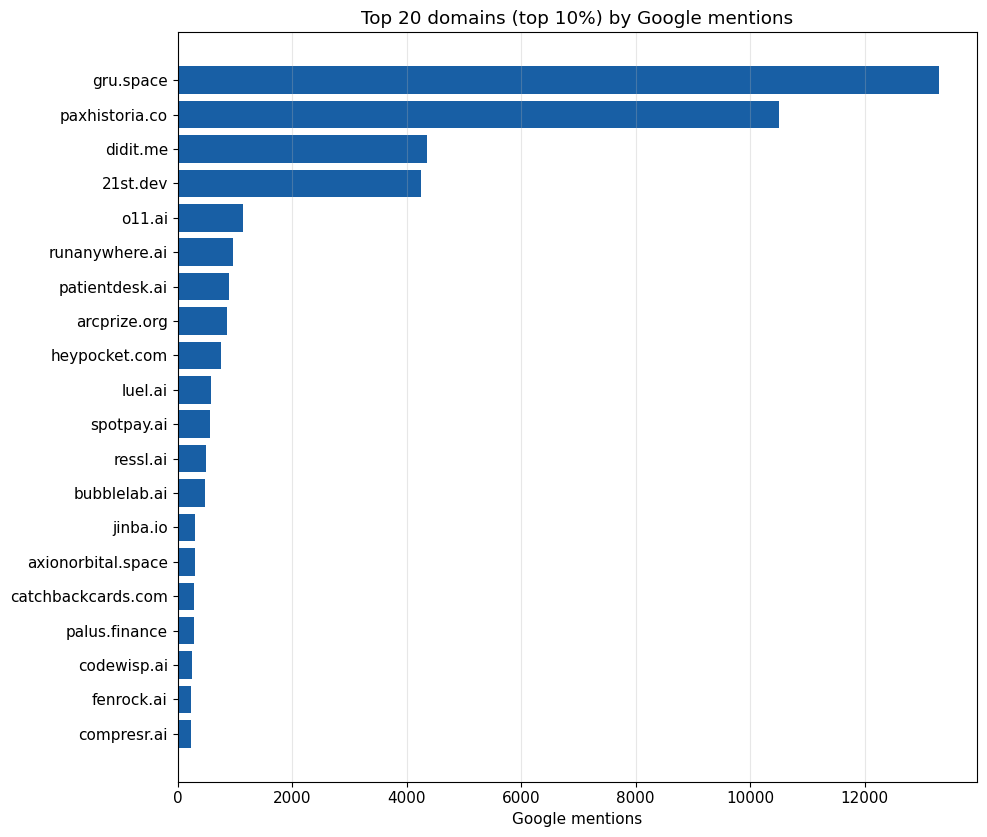

In [ ]:

plt.figure(figsize=(10, len(top_10pct) * 0.35 + 1.5))
plt.barh(top_10pct['domain'], top_10pct['google_mentions'], color=COL_MENTIONS_DEMO)
plt.gca().invert_yaxis()
plt.title(f'Top {n_top} domains (top 10%) by Google mentions')
plt.xlabel('Google mentions')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

# Extract values for math
values = df["google_mentions"].values
total_mentions = df["google_mentions"].sum()

# ---- 1. Gini Coefficient ----
def gini(x):
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

gini_coeff = gini(values)

# ---- 2. Concentration (Top 10% and Top 2%) ----
# Top 10%
n_top_10 = 20 #int(len(df) * 0.1)
top_10_share = df.head(n_top_10)["google_mentions"].sum() / total_mentions

# Top 2%
n_top_2 = 4 # int(len(df) * 0.02)
top_2_share = df.head(n_top_2)["google_mentions"].sum() / total_mentions

# ---- Print Results ----
print("=== YC W26 Attention Inequality ===")
print(f"Total Mentions: {total_mentions:,}")
print(f"Gini Coefficient: {gini_coeff:.3f} (Values closer to 1 indicate extreme inequality)")
print("-" * 35)
print(f"Top 10% of startups ({n_top_10} companies) capture {top_10_share:.2%} of all mentions.")
print(f"Top 2% of startups ({n_top_2} companies) capture {top_2_share:.2%} of all mentions.")

=== YC W26 Attention Inequality ===
Total Mentions: 50,293
Gini Coefficient: 0.854 (Values closer to 1 indicate extreme inequality)
-----------------------------------
Top 10% of startups (20 companies) capture 81.73% of all mentions.
Top 2% of startups (4 companies) capture 64.44% of all mentions.


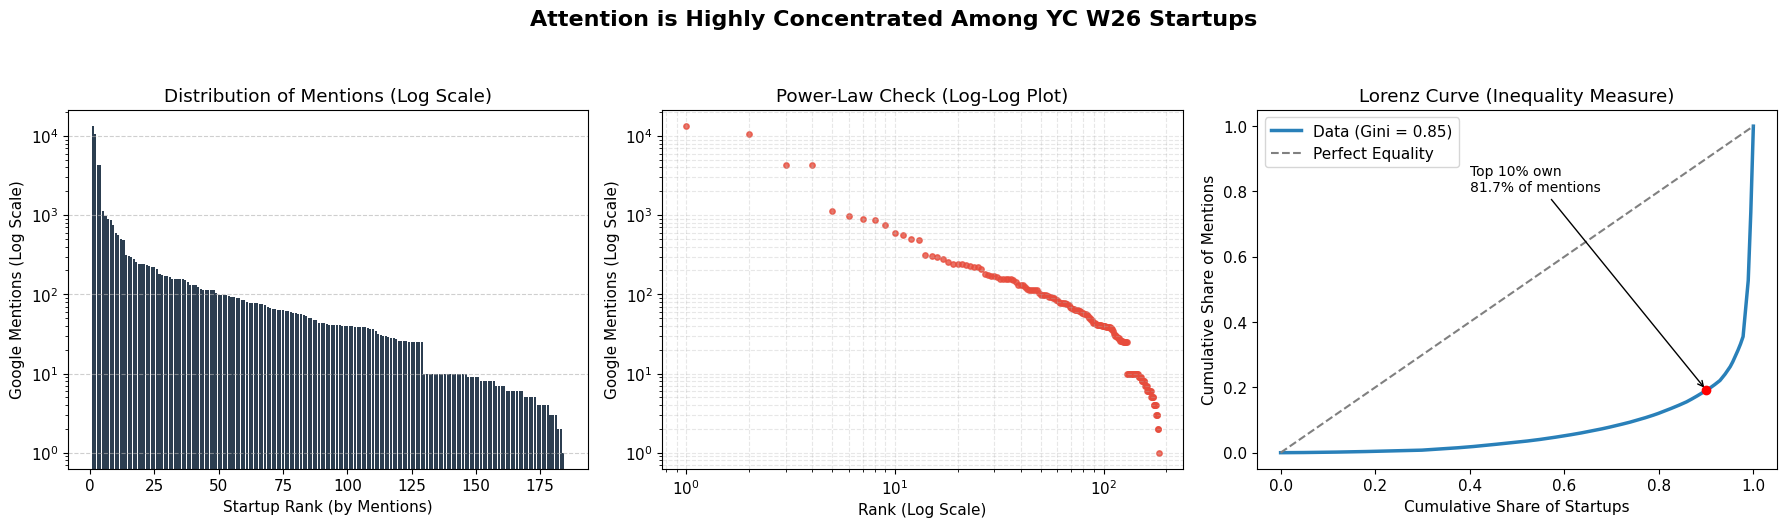

In [ ]:

# Set up a 1x3 grid for the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.rcParams.update({'font.size': 11})

ranks = np.arange(1, len(values) + 1)
sorted_vals_asc = np.sort(values) # Ascending for Lorenz curve

# ---- Plot 1: Rank-Size Bar Chart (Log Scale) ----
axes[0].bar(ranks, values, color="#2c3e50")
axes[0].set_yscale("log")
axes[0].set_xlabel("Startup Rank (by Mentions)")
axes[0].set_ylabel("Google Mentions (Log Scale)")
axes[0].set_title("Distribution of Mentions (Log Scale)")
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# ---- Plot 2: Log-Log Plot (Power-Law Check) ----
axes[1].scatter(ranks, values, s=15, color="#e74c3c", alpha=0.8)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Rank (Log Scale)")
axes[1].set_ylabel("Google Mentions (Log Scale)")
axes[1].set_title("Power-Law Check (Log-Log Plot)")
axes[1].grid(True, which="both", linestyle="--", alpha=0.3)

# ---- Plot 3: Lorenz Curve ----
cumvals = np.cumsum(sorted_vals_asc)
cumvals = np.insert(cumvals, 0, 0) # Start at 0
cumvals = cumvals / cumvals[-1] # Normalize
x_lorenz = np.linspace(0, 1, len(cumvals))

axes[2].plot(x_lorenz, cumvals, linewidth=2.5, color="#2980b9", label=f"Data (Gini = {gini_coeff:.2f})")
axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Equality")

# Highlight Top 10% on Lorenz
axes[2].scatter(0.9, cumvals[int(len(cumvals)*0.9)], color="red", zorder=5)
axes[2].annotate(f'Top 10% own\n{top_10_share:.1%} of mentions',
            xy=(0.9, cumvals[int(len(cumvals)*0.9)]), xytext=(0.4, 0.8),
            arrowprops=dict(facecolor='black', arrowstyle="->"), fontsize=10)

axes[2].set_xlabel("Cumulative Share of Startups")
axes[2].set_ylabel("Cumulative Share of Mentions")
axes[2].set_title("Lorenz Curve (Inequality Measure)")
axes[2].legend(loc="upper left")

plt.suptitle("Attention is Highly Concentrated Among YC W26 Startups", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

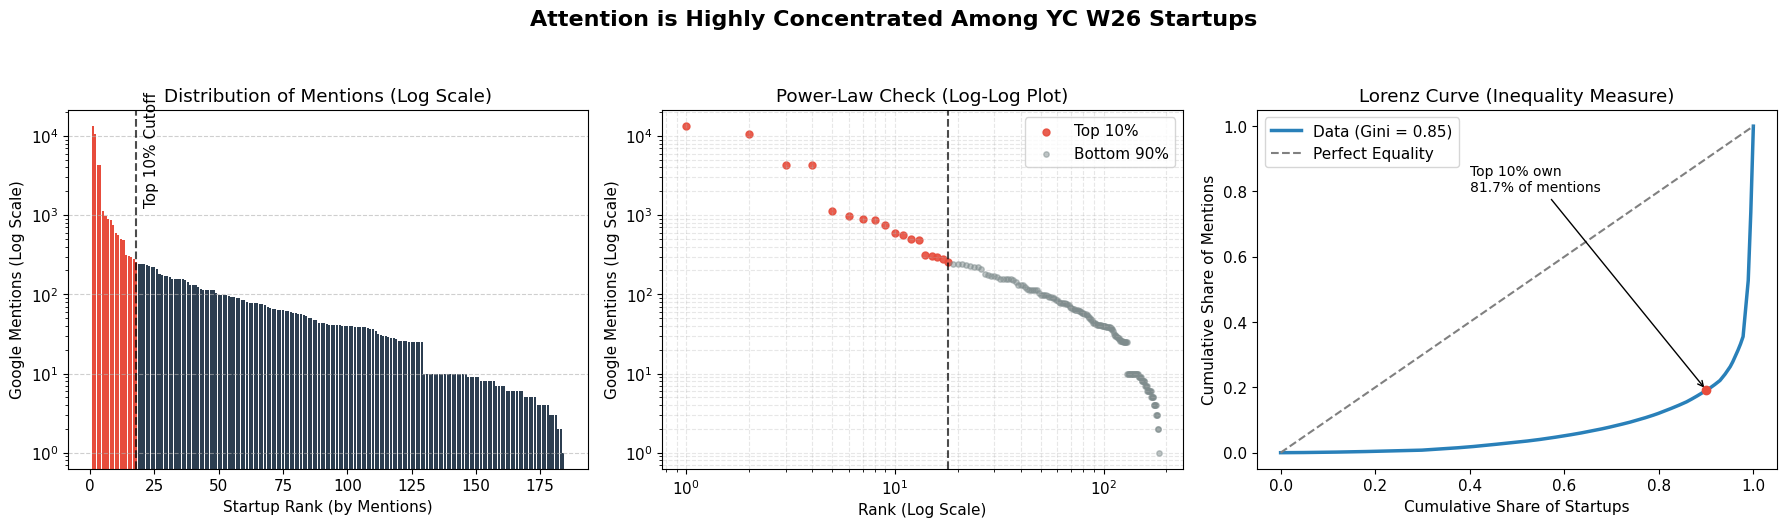

In [ ]:

# Set up a 1x3 grid for the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.rcParams.update({'font.size': 11})

ranks = np.arange(1, len(values) + 1)
sorted_vals_asc = np.sort(values) # Ascending for Lorenz curve

# ---- Calculate Cutoffs ----
cutoff_index = int(len(values) * 0.1)

# ---- Plot 1: Rank-Size Bar Chart (Log Scale) ----
# Highlight the top 10% bars in red, the rest in standard dark blue
colors = ['#e74c3c' if i <= cutoff_index else '#2c3e50' for i in ranks]
axes[0].bar(ranks, values, color=colors)
axes[0].set_yscale("log")
# Add the vertical cutoff line
axes[0].axvline(x=cutoff_index, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0].text(cutoff_index + 3, max(values)/2, 'Top 10% Cutoff', color='black', rotation=90, verticalalignment='center')
axes[0].set_xlabel("Startup Rank (by Mentions)")
axes[0].set_ylabel("Google Mentions (Log Scale)")
axes[0].set_title("Distribution of Mentions (Log Scale)")
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# ---- Plot 2: Log-Log Plot (Power-Law Check) ----
# Plot top 10% and bottom 90% separately to give them distinct colors/labels
axes[1].scatter(ranks[:cutoff_index], values[:cutoff_index], s=25, color="#e74c3c", alpha=0.9, label="Top 10%")
axes[1].scatter(ranks[cutoff_index:], values[cutoff_index:], s=15, color="#7f8c8d", alpha=0.5, label="Bottom 90%")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
# Add the vertical cutoff line
axes[1].axvline(x=cutoff_index, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].set_xlabel("Rank (Log Scale)")
axes[1].set_ylabel("Google Mentions (Log Scale)")
axes[1].set_title("Power-Law Check (Log-Log Plot)")
axes[1].legend()
axes[1].grid(True, which="both", linestyle="--", alpha=0.3)

# ---- Plot 3: Lorenz Curve ----
cumvals = np.cumsum(sorted_vals_asc)
cumvals = np.insert(cumvals, 0, 0) # Start at 0
cumvals = cumvals / cumvals[-1] # Normalize
x_lorenz = np.linspace(0, 1, len(cumvals))

axes[2].plot(x_lorenz, cumvals, linewidth=2.5, color="#2980b9", label=f"Data (Gini = {gini_coeff:.2f})")
axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Equality")

# Highlight Top 10% on Lorenz (which is the x=0.9 mark for the bottom 90% cumulative)
axes[2].scatter(0.9, cumvals[int(len(cumvals)*0.9)], color="#e74c3c", zorder=5)
axes[2].annotate(f'Top 10% own\n{top_10_share:.1%} of mentions',
            xy=(0.9, cumvals[int(len(cumvals)*0.9)]), xytext=(0.4, 0.8),
            arrowprops=dict(facecolor='black', arrowstyle="->"), fontsize=10)

axes[2].set_xlabel("Cumulative Share of Startups")
axes[2].set_ylabel("Cumulative Share of Mentions")
axes[2].set_title("Lorenz Curve (Inequality Measure)")
axes[2].legend(loc="upper left")

plt.suptitle("Attention is Highly Concentrated Among YC W26 Startups", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

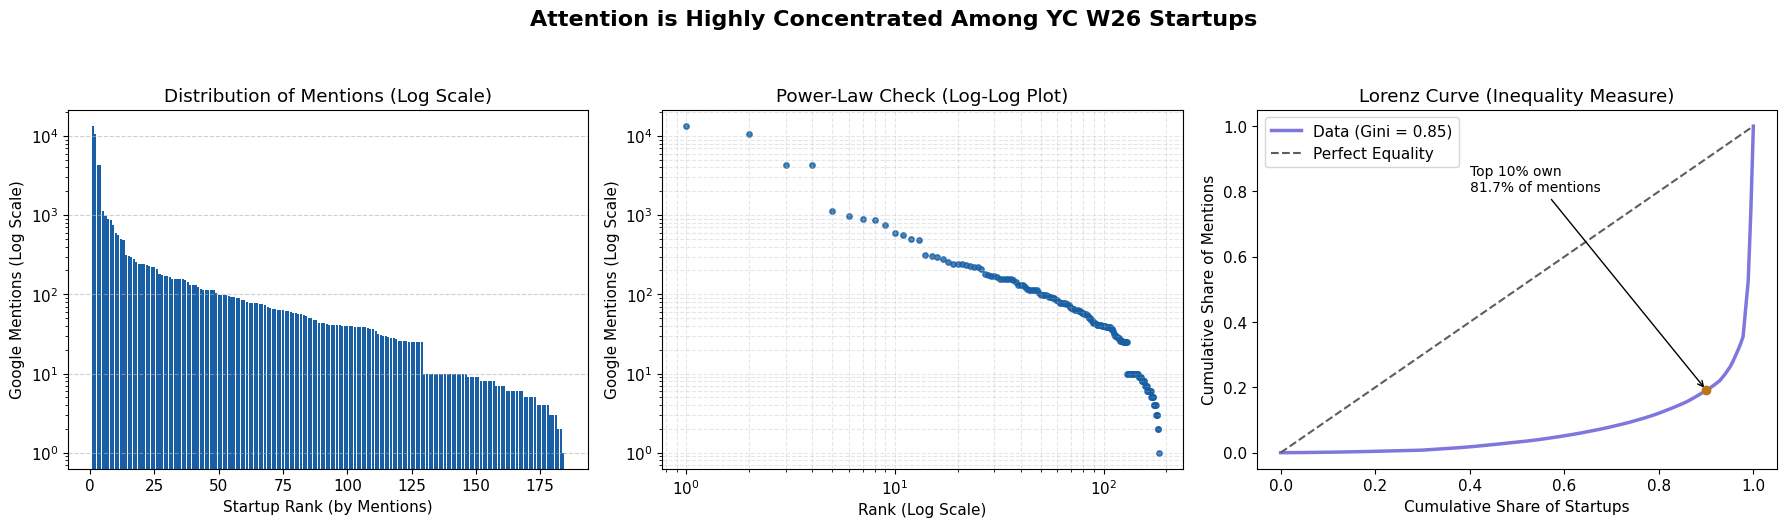

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.rcParams.update({'font.size': 11})

ranks = np.arange(1, len(values) + 1)
sorted_vals_asc = np.sort(values)

# Plot 1: rank-size bar
axes[0].bar(ranks, values, color=COL_MENTIONS_DEMO)
axes[0].set_yscale("log")
axes[0].set_xlabel("Startup Rank (by Mentions)")
axes[0].set_ylabel("Google Mentions (Log Scale)")
axes[0].set_title("Distribution of Mentions (Log Scale)")
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# Plot 2: log-log scatter
axes[1].scatter(ranks, values, s=15, color=COL_MENTIONS_DEMO, alpha=0.8)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Rank (Log Scale)")
axes[1].set_ylabel("Google Mentions (Log Scale)")
axes[1].set_title("Power-Law Check (Log-Log Plot)")
axes[1].grid(True, which="both", linestyle="--", alpha=0.3)

# Plot 3: Lorenz curve
cumvals = np.cumsum(sorted_vals_asc)
cumvals = np.insert(cumvals, 0, 0)
cumvals = cumvals / cumvals[-1]
x_lorenz = np.linspace(0, 1, len(cumvals))

axes[2].plot(x_lorenz, cumvals, linewidth=2.5, color=COL_TRACTION,
             label=f"Data (Gini = {gini_coeff:.2f})")
axes[2].plot([0, 1], [0, 1], linestyle="--", color=COL_CUTOFF, label="Perfect Equality")
axes[2].scatter(0.9, cumvals[int(len(cumvals) * 0.9)], color=COL_MISSED, zorder=5)
axes[2].annotate(
    f'Top 10% own\n{top_10_share:.1%} of mentions',
    xy=(0.9, cumvals[int(len(cumvals) * 0.9)]),
    xytext=(0.4, 0.8),
    arrowprops=dict(facecolor=COL_CUTOFF, arrowstyle="->"),
    fontsize=10
)
axes[2].set_xlabel("Cumulative Share of Startups")
axes[2].set_ylabel("Cumulative Share of Mentions")
axes[2].set_title("Lorenz Curve (Inequality Measure)")
axes[2].legend(loc="upper left")

plt.suptitle("Attention is Highly Concentrated Among YC W26 Startups",
             fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

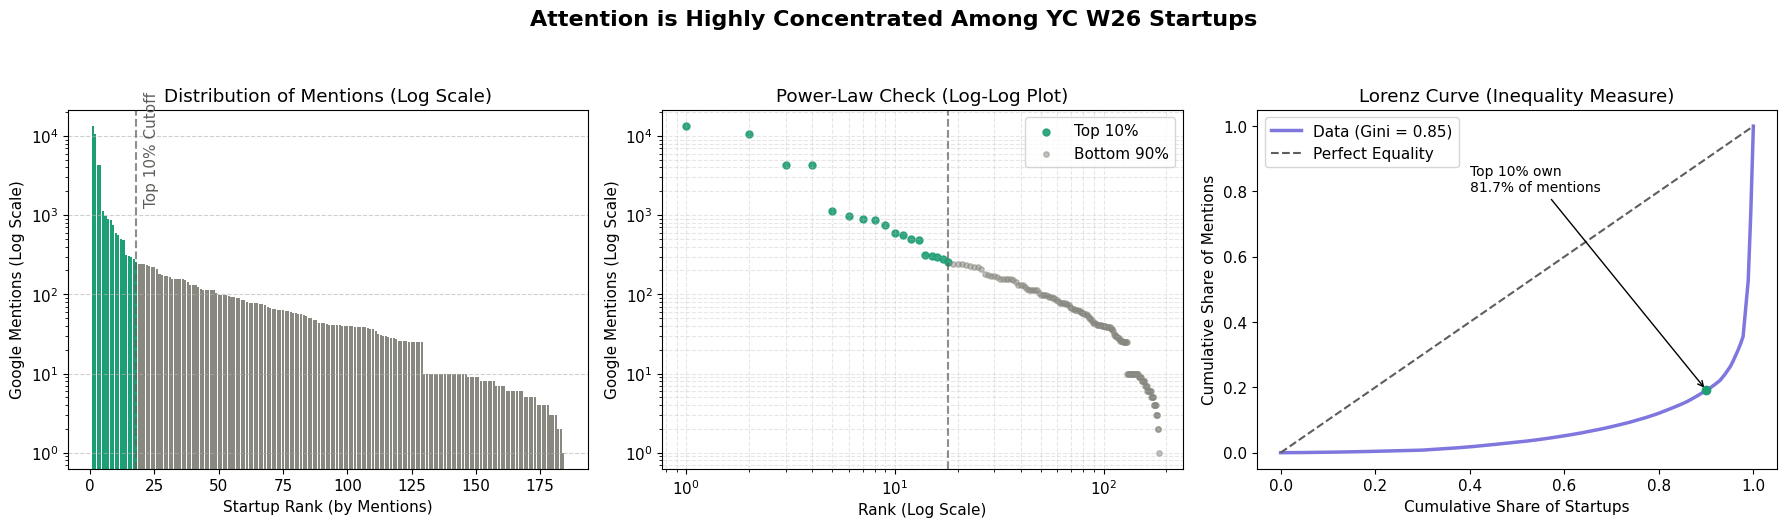

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ranks = np.arange(1, len(values) + 1)
sorted_vals_asc = np.sort(values)
cutoff_index = int(len(values) * 0.1)

# Plot 1: rank-size bar with top-10% highlight
bar_colors = [COL_TOP if i <= cutoff_index else COL_REST for i in ranks]
axes[0].bar(ranks, values, color=bar_colors)
axes[0].set_yscale("log")
axes[0].axvline(x=cutoff_index, color=COL_CUTOFF, linestyle='--', linewidth=1.5, alpha=0.7)
axes[0].text(cutoff_index + 3, max(values) / 2, 'Top 10% Cutoff',
             color=COL_CUTOFF, rotation=90, verticalalignment='center')
axes[0].set_xlabel("Startup Rank (by Mentions)")
axes[0].set_ylabel("Google Mentions (Log Scale)")
axes[0].set_title("Distribution of Mentions (Log Scale)")
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# Plot 2: log-log scatter with top-10% highlight
axes[1].scatter(ranks[:cutoff_index], values[:cutoff_index],
                s=25, color=COL_TOP, alpha=0.9, label="Top 10%")
axes[1].scatter(ranks[cutoff_index:], values[cutoff_index:],
                s=15, color=COL_REST, alpha=0.5, label="Bottom 90%")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].axvline(x=cutoff_index, color=COL_CUTOFF, linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].set_xlabel("Rank (Log Scale)")
axes[1].set_ylabel("Google Mentions (Log Scale)")
axes[1].set_title("Power-Law Check (Log-Log Plot)")
axes[1].legend()
axes[1].grid(True, which="both", linestyle="--", alpha=0.3)

# Plot 3: Lorenz curve
cumvals = np.cumsum(sorted_vals_asc)
cumvals = np.insert(cumvals, 0, 0)
cumvals = cumvals / cumvals[-1]
x_lorenz = np.linspace(0, 1, len(cumvals))

axes[2].plot(x_lorenz, cumvals, linewidth=2.5, color=COL_TRACTION,
             label=f"Data (Gini = {gini_coeff:.2f})")
axes[2].plot([0, 1], [0, 1], linestyle="--", color=COL_CUTOFF, label="Perfect Equality")
axes[2].scatter(0.9, cumvals[int(len(cumvals) * 0.9)], color=COL_TOP, zorder=5)
axes[2].annotate(
    f'Top 10% own\n{top_10_share:.1%} of mentions',
    xy=(0.9, cumvals[int(len(cumvals) * 0.9)]),
    xytext=(0.4, 0.8),
    arrowprops=dict(facecolor=COL_CUTOFF, arrowstyle="->"),
    fontsize=10
)
axes[2].set_xlabel("Cumulative Share of Startups")
axes[2].set_ylabel("Cumulative Share of Mentions")
axes[2].set_title("Lorenz Curve (Inequality Measure)")
axes[2].legend(loc="upper left")

plt.suptitle("Attention is Highly Concentrated Among YC W26 Startups",
             fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

#Factoring in "leaked" traction data from Lobster Capital

https://open.substack.com/pub/lobstercap/p/yc-w26-the-definitive-investors-guide?utm_source=share&utm_medium=android&r=3nykw

In [ ]:

import pandas as pd
import numpy as np

# ── Data (corrected from Lobster Capital article) ──────────────────────────────
data = {
    'Startup': [
        'Pocket', 'Avoice', 'Mango Medical', 'OctaPulse', 'Luel',
        'Pax Historia', 'Didit', '21st', 'OpenSpec', 'Samora AI', 'Corvera'
    ],
    # Revenue signals
    'arr':             [27000000, 240000, 0,        0,      0,      0, 0, 0, 0,       0, 300000],  # $27M (Pocket), $240K (Avoice)
    'pilot_revenue':   [0,        0,      0,        100000, 0,      0, 0, 0, 0,       0, 0],  # 6-figure pilot (OctaPulse)
    'loi':             [0,        0,      10000000, 0,      0,      0, 0, 0, 0,       0, 0],  # $10M LOI (Mango Medical)

    # User signals — split into 3 distinct types
    'signups':         [0,        0,      0,        0,      190000, 0, 0, 1000000, 0, 0, 0],  # registered accounts (Luel, 21st)
    'active_users':    [0,        0,      0,        0,      0,      35000, 0, 0,    0, 0, 0],  # DAU (Pax Historia)
    'activity_volume': [0,        0,      0,        0,      0,      0, 4000000, 0,  0, 1000000, 0],  # transactions/calls (Didit, Samora AI)

    # Ecosystem signal
    'ecosystem_pull':  [0,        0,      0,        0,      0,      0, 0, 0, 30000,  0, 0],   # GitHub stars (OpenSpec)
}

df = pd.DataFrame(data)

# ── VC Weights ─────────────────────────────────────────────────────────────────
# Logic: revenue > engagement > volume > acquisition > ecosystem
vc_weights = {
    'arr':             1.00,  # proven monetization
    'pilot_revenue':   0.50,  # paid but not recurring yet
    'loi':             0.20,  # intent, not cash
    'active_users':    0.40,  # retention signal
    'activity_volume': 0.25,  # scale signal (API calls, verifications)
    'signups':         0.15,  # acquisition only, no retention proof
    'ecosystem_pull':  0.10,  # awareness / distribution
}

In [ ]:

def compute_vc_score(row):
    weighted_metrics = {}

    for metric, weight in vc_weights.items():

        # 2. Apply VC Weight
        weighted_metrics[metric] = row[metric] * weight


    # Final score is the MAX of weighted metrics per your instruction
    return max(weighted_metrics.values())

# Apply the logic
df['Score'] = df.apply(compute_vc_score, axis=1)
df['Log_Score'] = np.log10(df['Score'].replace(0, 1)).round(2)

# Sort by Score
df_ranked = df.sort_values(by='Score', ascending=False).reset_index(drop=True)
df_ranked[['Startup', 'Score', 'Log_Score']]

,Startup,Score,Log_Score
0,Pocket,27000000.0,7.43
1,Mango Medical,2000000.0,6.30
2,Didit,1000000.0,6.00
3,Corvera,300000.0,5.48
4,Samora AI,250000.0,5.40
5,Avoice,240000.0,5.38
6,21st,150000.0,5.18
7,OctaPulse,50000.0,4.70
8,Luel,28500.0,4.45
9,Pax Historia,14000.0,4.15


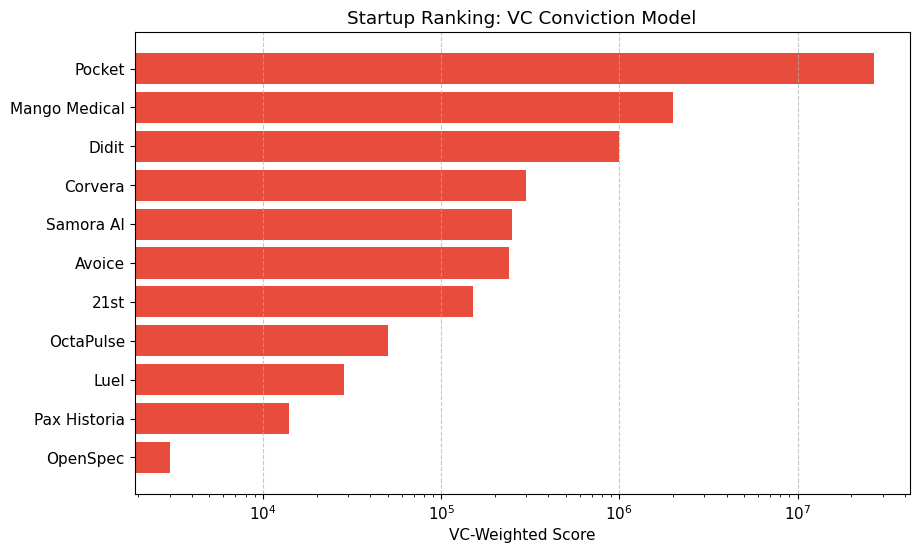

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
#colors = ['
plt.barh(df_ranked['Startup'][::-1], df_ranked['Score'][::-1], color=colors)
plt.xlabel('VC-Weighted Score')
plt.title('Startup Ranking: VC Conviction Model')
plt.xscale('log') # Log scale helps visualize the massive gaps between ARR and Users
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:

# 1. Define the MoM growth mapping
# Only Pocket has an explicit MoM figure from the Lobster Capital guide (50%).
# All others: no MoM reported → default to 0.
growth_map = {
    'Pocket': 0.50,        # Explicit 50% MoM growth (from $27M ARR, 30k units in ~5 months)
    'Avoice': 0.0,
    'OctaPulse': 0.0,
    'OpenSpec': 0.0,
    'Mango Medical': 0.0,
    'Pax Historia': 0.0,
    'Luel': 0.0,
    'Didit': 0.0,          # No indication of stagnation/churn; millions verified monthly (positive signal)
    '21st': 0.0,
    'Samora AI': 0.0,
    'Corvera': 0.0
}

# 2. Add the column to the DataFrame safely
# This ensures 'mom_growth' exists so you don't get a KeyError
df['mom_growth'] = df['Startup'].map(growth_map).fillna(0)


def compute_velocity_score(row):
    base_score = row['Score']
    # Use .get() or direct access now that column is guaranteed to exist
    mom = row['mom_growth']

    # Your Formula: (1 + 10 * MoM)
    velocity_multiplier = (1 + 10 * mom)

    # Floor at 0.1 to avoid negative or zeroed-out scores for shrinking companies
    velocity_multiplier = max(velocity_multiplier, 0.1)

    return base_score * velocity_multiplier

# 3. Re-calculate scores
df['Velocity_Score'] = df.apply(compute_velocity_score, axis=1)
df['Final_Log_Score'] = np.log10(df['Velocity_Score'].replace(0, 1)).round(2)

# 4. Display Results
df_velocity_ranked = df.sort_values(by='Velocity_Score', ascending=False).reset_index(drop=True)
df_velocity_ranked[['Startup', 'mom_growth', 'Score', 'Velocity_Score', 'Final_Log_Score']]

,Startup,mom_growth,Score,Velocity_Score,Final_Log_Score
0,Pocket,0.5,27000000.0,162000000.0,8.21
1,Mango Medical,0.0,2000000.0,2000000.0,6.30
2,Didit,0.0,1000000.0,1000000.0,6.00
3,Corvera,0.0,300000.0,300000.0,5.48
4,Samora AI,0.0,250000.0,250000.0,5.40
5,Avoice,0.0,240000.0,240000.0,5.38
6,21st,0.0,150000.0,150000.0,5.18
7,OctaPulse,0.0,50000.0,50000.0,4.70
8,Luel,0.0,28500.0,28500.0,4.45
9,Pax Historia,0.0,14000.0,14000.0,4.15


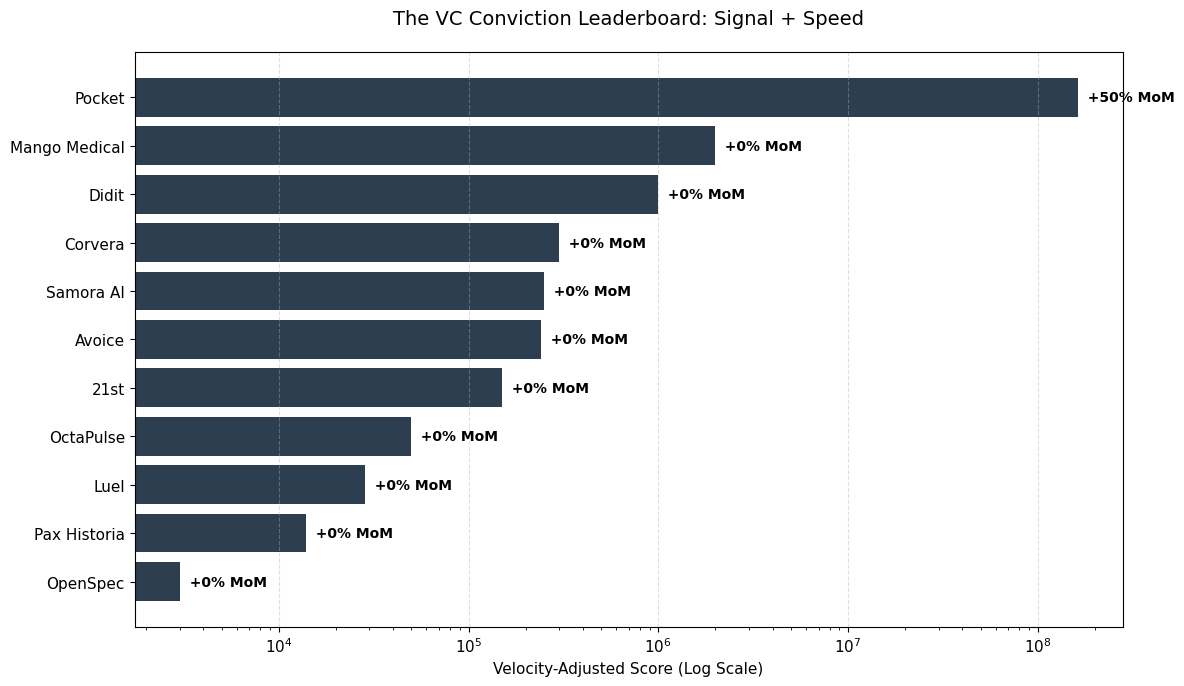

In [ ]:

import matplotlib.pyplot as plt

# Using the new velocity-ranked dataframe
plt.figure(figsize=(12, 7))

# Dynamic color logic: Green for the "VC Conviction" zone, Orange for "Caution/Stagnant"
# Adjusted threshold to 100k for the new Velocity_Score scale
#colors = ['#2ecc71' if x > 100000 else '#e67e22' for x in df_velocity_ranked['Velocity_Score']]

# Horizontal bar chart (plotted in reverse to keep rank #1 at the top)
plt.barh(df_velocity_ranked['Startup'][::-1],
         df_velocity_ranked['Velocity_Score'][::-1],
         color=colors[::-1])

# Adding the MoM labels to the bars for context
for i, (val, mom) in enumerate(zip(df_velocity_ranked['Velocity_Score'][::-1],
                                   df_velocity_ranked['mom_growth'][::-1])):
    plt.text(val, i, f'  {mom:+.0%} MoM', va='center', fontsize=10, fontweight='bold')

plt.xlabel('Velocity-Adjusted Score (Log Scale)')
plt.title('The VC Conviction Leaderboard: Signal + Speed', fontsize=14, pad=20)
plt.xscale('log')
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Tight layout to prevent label clipping
plt.tight_layout()
plt.show()

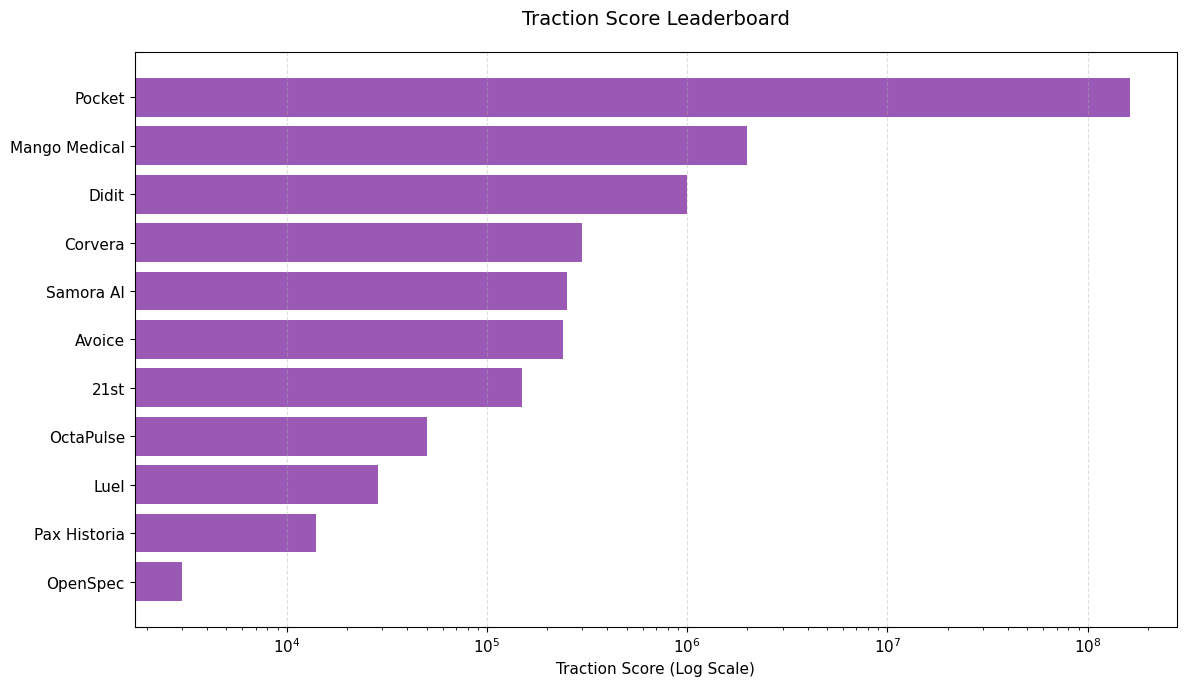

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# All bars in the same purple
plt.barh(
    df_velocity_ranked['Startup'][::-1],
    df_velocity_ranked['Velocity_Score'][::-1],
    color='#9b59b6'          # nice rich purple (or '#8e44ad', '#6a1b9a', etc.)
    # alternatively: color='purple', 'mediumpurple', 'darkviolet', 'indigo'
)


plt.xlabel('Traction Score (Log Scale)')
plt.title('Traction Score Leaderboard', fontsize=14, pad=20)
plt.xscale('log')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

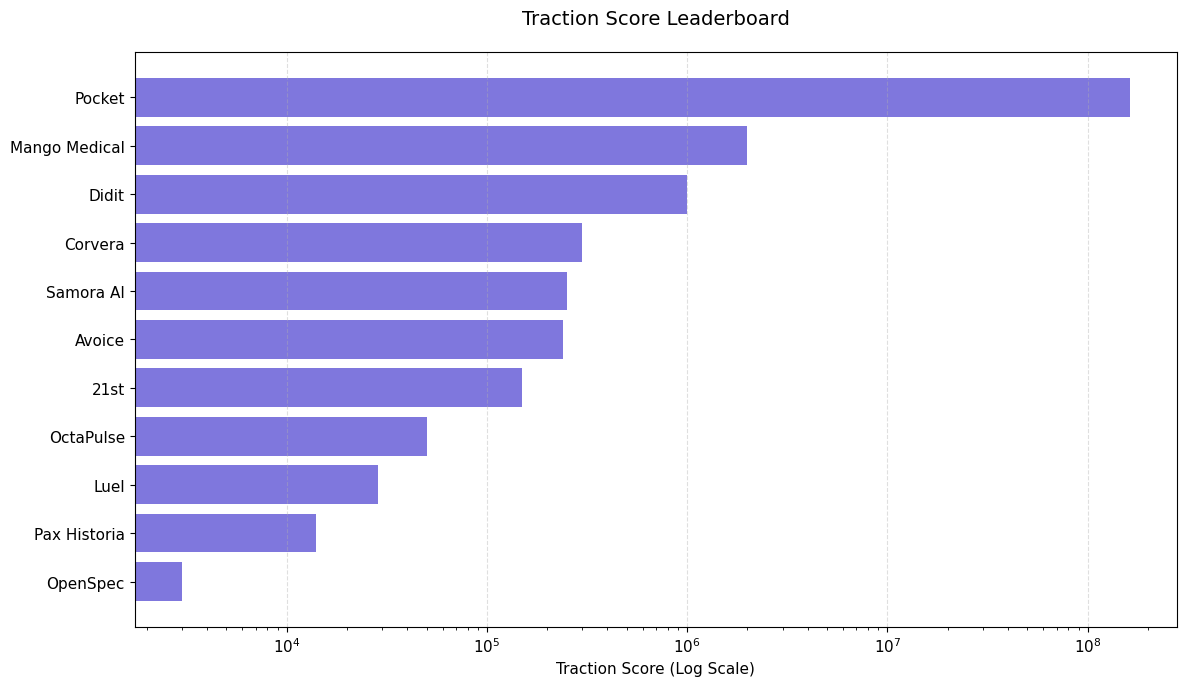

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# All bars in the same purple
plt.barh(
    df_velocity_ranked['Startup'][::-1],
    df_velocity_ranked['Velocity_Score'][::-1],
    color=COL_TRACTION        # nice rich purple (or '#8e44ad', '#6a1b9a', etc.)
    # alternatively: color='purple', 'mediumpurple', 'darkviolet', 'indigo'
)


plt.xlabel('Traction Score (Log Scale)')
plt.title('Traction Score Leaderboard', fontsize=14, pad=20)
plt.xscale('log')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

#Combining Google Mentions and other Traction signals into a Pre-Demo Score

Total startups with signal: 184
Top 10% (20 startups)



,rank,domain,google_mentions,Velocity_Score,mentions_score,hybrid_score,log_hybrid_score
0,1,heypocket.com,755,162000000.0,37.75,1.620000e+08,8.209515
1,2,mangomedical.io,3,2000000.0,0.15,2.000000e+06,6.301030
2,3,didit.me,4350,1000000.0,217.50,1.000000e+06,6.000000
3,4,corvera.ai,64,300000.0,3.20,3.000000e+05,5.477121
4,5,samora.ai,171,250000.0,8.55,2.500000e+05,5.397940
5,6,avoice.co,36,240000.0,1.80,2.400000e+05,5.380211
6,7,21st.dev,4260,150000.0,213.00,1.500000e+05,5.176091
7,8,tryoctapulse.com,10,50000.0,0.50,5.000000e+04,4.698970
8,9,luel.ai,591,28500.0,29.55,2.850000e+04,4.454845
9,10,paxhistoria.co,10500,14000.0,525.00,1.400000e+04,4.146128


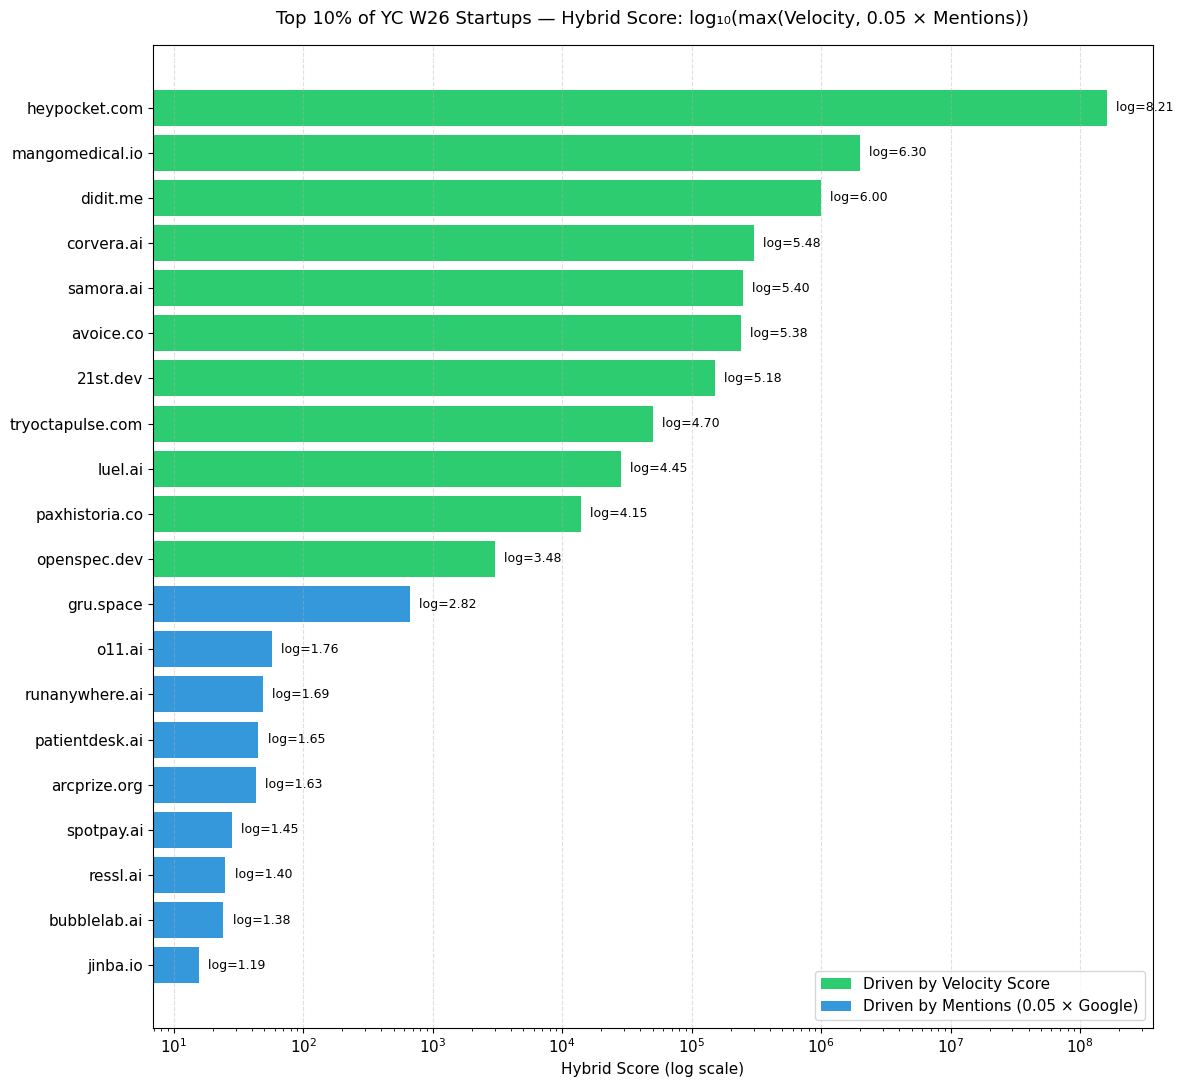

In [ ]:

"""# Combining Google Mentions and other Traction signals into a Pre-Demo Score"""

# ── 1. Rebuild the full Google mentions dataframe ─────────────────────────────
lines_mentions = [line.split(": ") for line in raw_data.strip().split("\n")]
df_mentions = pd.DataFrame(lines_mentions, columns=["domain", "google_mentions"])
df_mentions["google_mentions"] = pd.to_numeric(df_mentions["google_mentions"])

# ── 2. Map each named startup to its domain & bring in velocity score ─────────
startup_to_domain = {
    'Pocket':       'heypocket.com',
    'Avoice':       'avoice.co',
    'Mango Medical':'mangomedical.io',
    'OctaPulse':    'tryoctapulse.com',
    'Luel':         'luel.ai',
    'Pax Historia': 'paxhistoria.co',
    'Didit':        'didit.me',
    '21st':         '21st.dev',
    'OpenSpec':     'openspec.dev',
    'Samora AI':    'samora.ai',
    'Corvera':    'corvera.ai'
}

df_velocity_lookup = df_velocity_ranked[['Startup', 'Velocity_Score']].copy()
df_velocity_lookup['domain'] = df_velocity_lookup['Startup'].map(startup_to_domain)

# ── 3. Merge velocity scores into the full mentions dataframe ─────────────────
df_hybrid = df_mentions.merge(
    df_velocity_lookup[['domain', 'Velocity_Score']],
    on='domain',
    how='left'
)
df_hybrid['Velocity_Score'] = df_hybrid['Velocity_Score'].fillna(0)

# ── 4. Compute the hybrid score ───────────────────────────────────────────────
# hybrid_score = max(velocity_score, 0.05 * google_mentions)  per domain
df_hybrid['mentions_score']  = df_hybrid['google_mentions'] * 0.05
df_hybrid['hybrid_score']    = df_hybrid[['Velocity_Score', 'mentions_score']].max(axis=1)
df_hybrid['log_hybrid_score'] = np.log10(df_hybrid['hybrid_score'].replace(0, np.nan))
#df_hybrid['log_hybrid_score'] = df_hybrid['hybrid_score'].replace(0, np.nan)
# Drop startups with no signal at all
df_hybrid = df_hybrid.dropna(subset=['log_hybrid_score'])

# ── 5. Select top 10% ────────────────────────────────────────────────────────
df_hybrid_sorted = df_hybrid.sort_values('hybrid_score', ascending=False).reset_index(drop=True)
top_n = 20 #max(1, round(len(df_hybrid_sorted) * 0.10))
df_top = df_hybrid_sorted.head(top_n).copy()
df_top['rank'] = df_top.index + 1

print(f"Total startups with signal: {len(df_hybrid_sorted)}")
print(f"Top 10% ({top_n} startups)\n")
display(df_top[['rank', 'domain', 'google_mentions', 'Velocity_Score', 'mentions_score', 'hybrid_score', 'log_hybrid_score']])

# ── 6. Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, len(df_top) * 0.45 + 2))

# Color: green if velocity score drove the result, blue if mentions did
bar_colors = [
    '#2ecc71' if row['Velocity_Score'] >= row['mentions_score'] else '#3498db'
    for _, row in df_top[::-1].iterrows()
]

bars = ax.barh(df_top['domain'][::-1], df_top['hybrid_score'][::-1], color=bar_colors)

# Annotate each bar with the log score
for i, (val, log_val) in enumerate(zip(df_top['hybrid_score'][::-1], df_top['log_hybrid_score'][::-1])):
    ax.text(val * 1.02, i, f'  log={log_val:.2f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Driven by Velocity Score'),
    Patch(facecolor='#3498db', label='Driven by Mentions (0.05 × Google)'),
]
ax.legend(handles=legend_elements, loc='lower right')

ax.set_xscale('log')
ax.set_xlabel('Hybrid Score (log scale)')
ax.set_title(
    f'Top 10% of YC W26 Startups — Hybrid Score: log₁₀(max(Velocity, 0.05 × Mentions))',
    fontsize=13, pad=15
)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

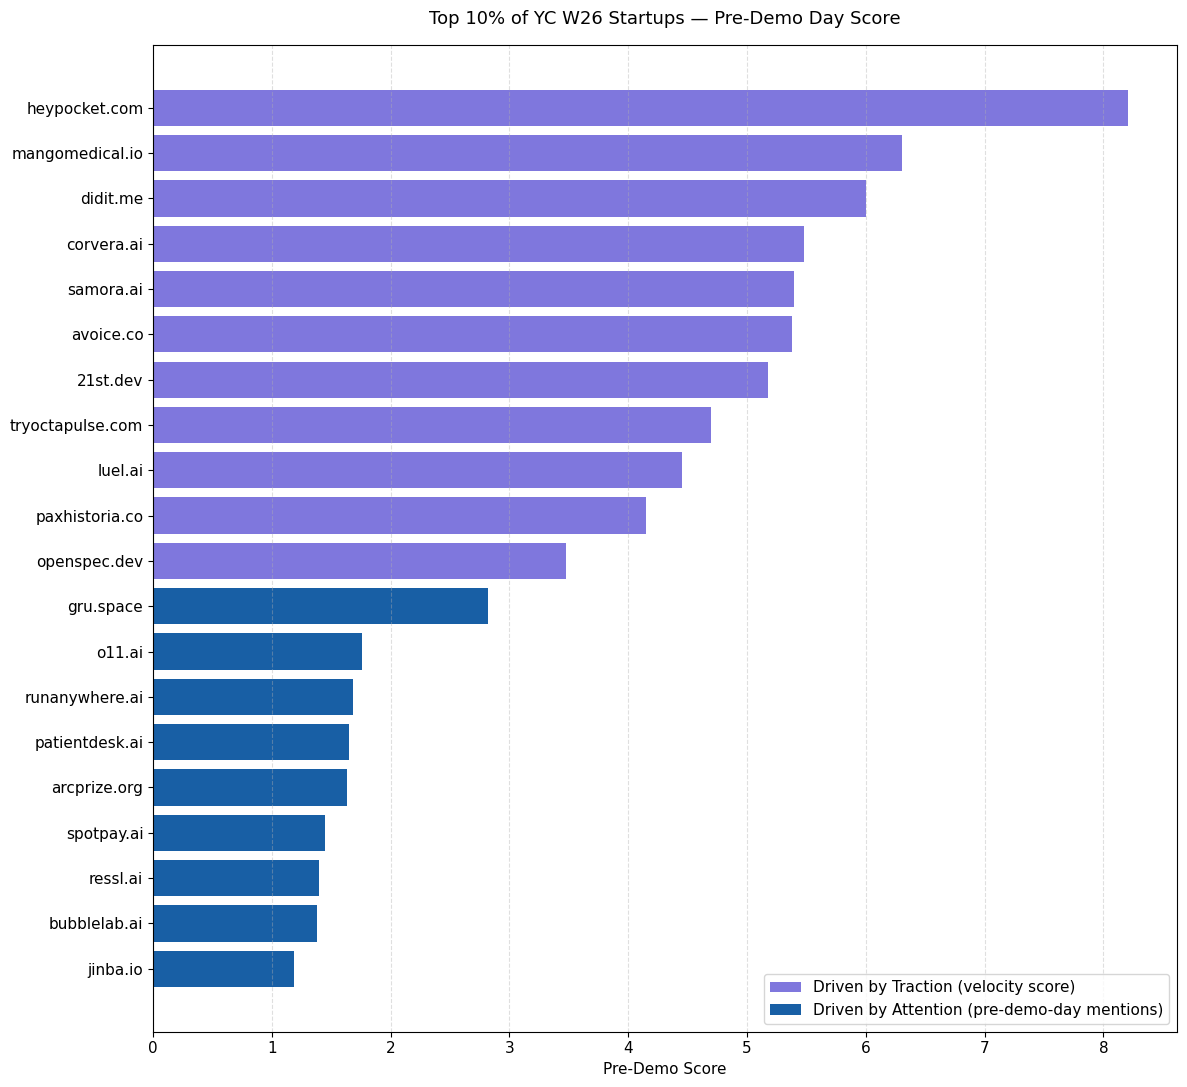

In [ ]:

from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, len(df_top) * 0.45 + 2))

bar_colors = [
    COL_TRACTION if row['Velocity_Score'] >= row['mentions_score'] else COL_MENTIONS_DEMO
    for _, row in df_top[::-1].iterrows()
]

ax.barh(df_top['domain'][::-1], df_top['log_hybrid_score'][::-1], color=bar_colors)

legend_elements = [
    Patch(facecolor=COL_TRACTION,      label='Driven by Traction (velocity score)'),
    Patch(facecolor=COL_MENTIONS_DEMO, label='Driven by Attention (pre-demo-day mentions)'),
]
ax.legend(handles=legend_elements, loc='lower right')

ax.set_xlabel('Pre-Demo Score')
ax.set_title('Top 10% of YC W26 Startups — Pre-Demo Day Score', fontsize=13, pad=15)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

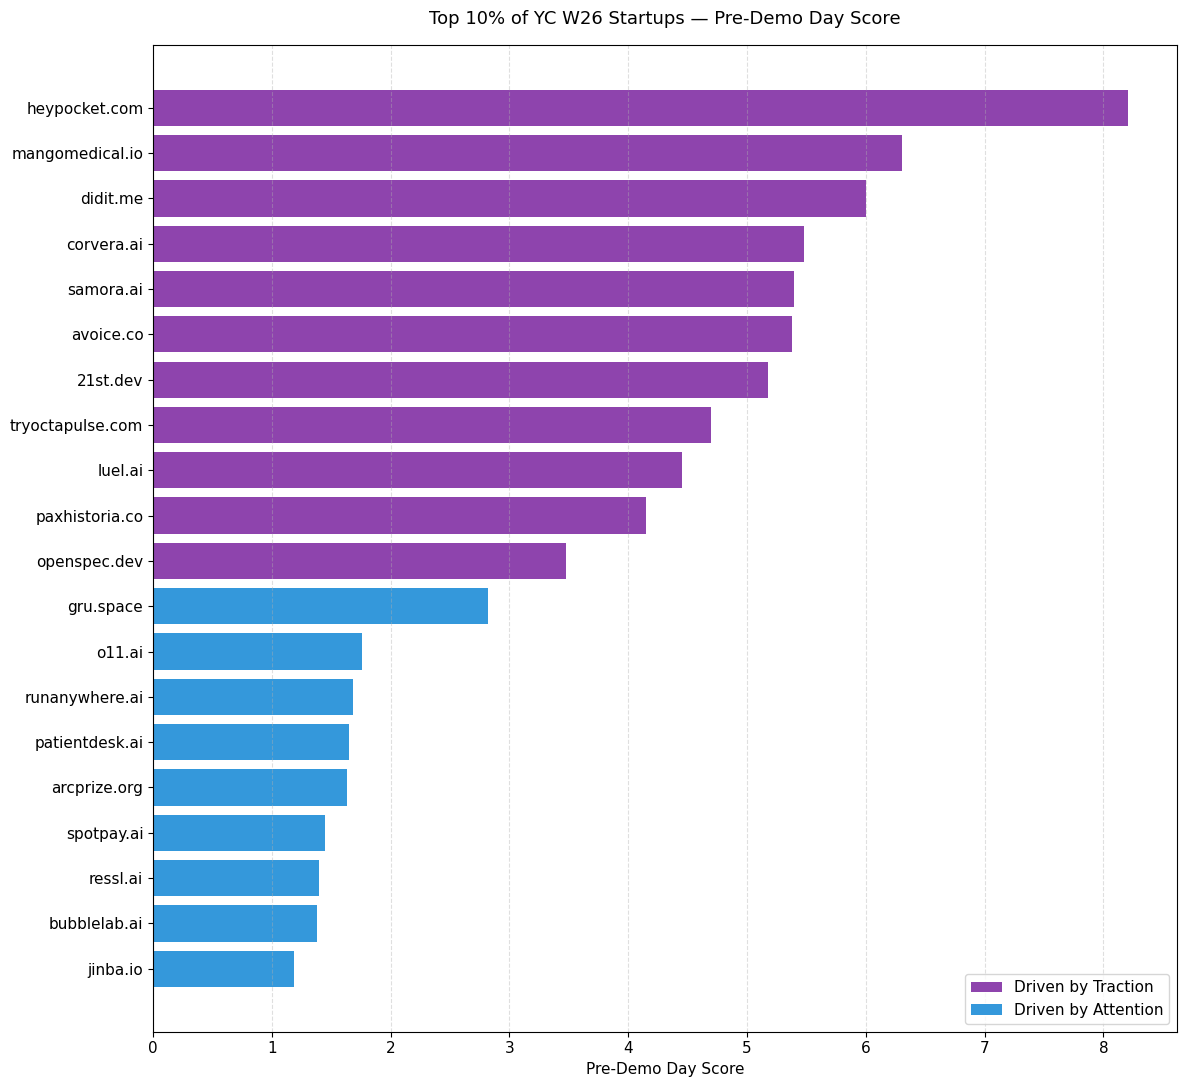

In [ ]:

# ── 6. Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, len(df_top) * 0.45 + 2))

bar_colors = [
    '#8e44ad' if row['Velocity_Score'] >= row['mentions_score'] else '#3498db'
    for _, row in df_top[::-1].iterrows()
]

# Plot log_hybrid_score directly on a linear axis
ax.barh(df_top['domain'][::-1], df_top['log_hybrid_score'][::-1], color=bar_colors)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#8e44ad', label='Driven by Traction'),
    Patch(facecolor='#3498db', label='Driven by Attention'),
]
ax.legend(handles=legend_elements, loc='lower right')

ax.set_xlabel('Pre-Demo Day Score')
ax.set_title(
    'Top 10% of YC W26 Startups — Pre-Demo Day Score',
    fontsize=13, pad=15
)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

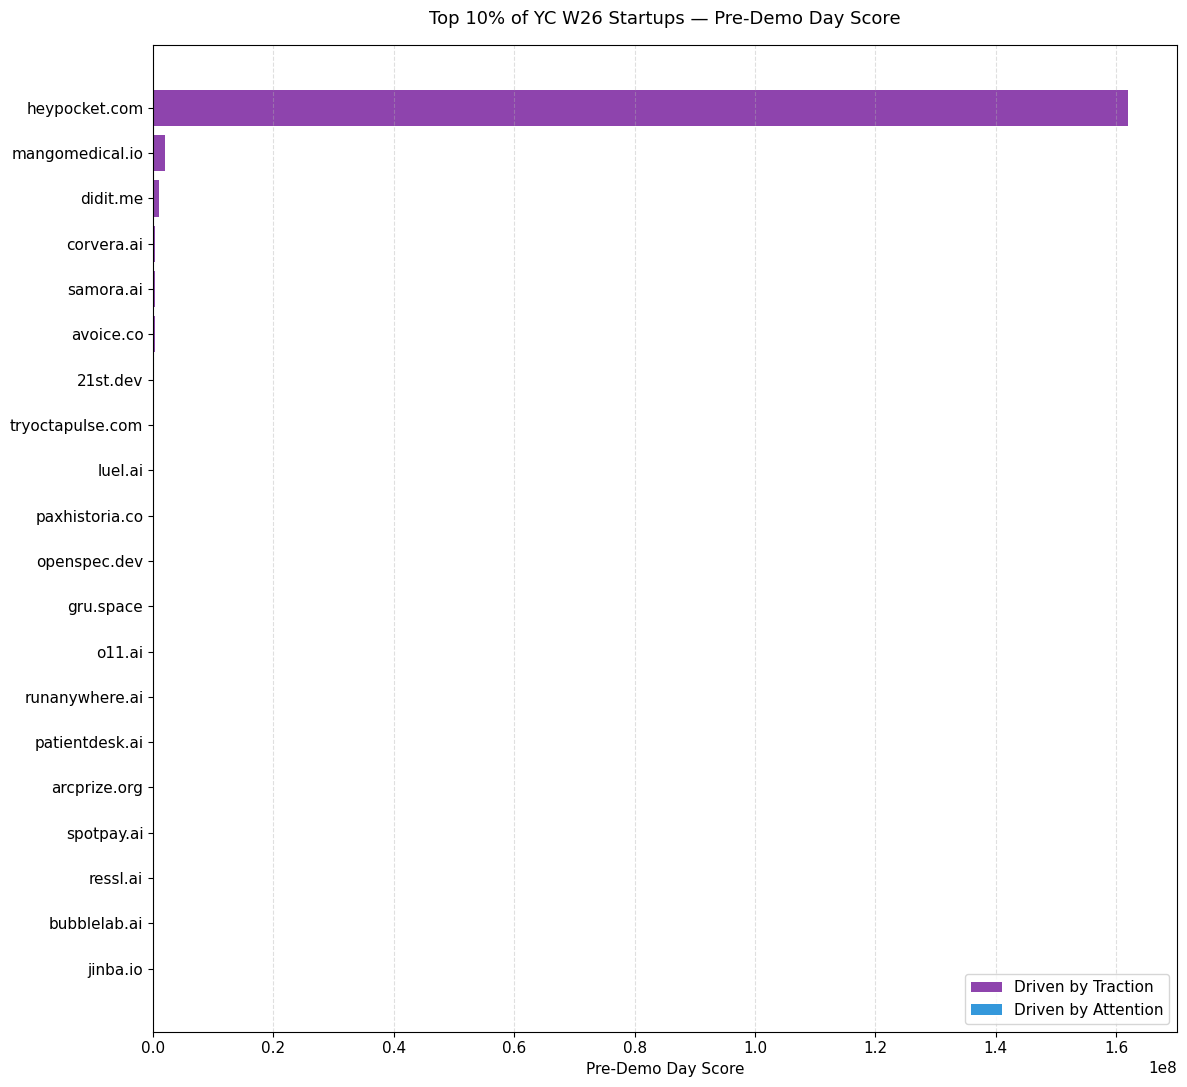

In [ ]:

# ── 6. Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, len(df_top) * 0.45 + 2))

bar_colors = [
    '#8e44ad' if row['Velocity_Score'] >= row['mentions_score'] else '#3498db'
    for _, row in df_top[::-1].iterrows()
]

# Plot log_hybrid_score directly on a linear axis
ax.barh(df_top['domain'][::-1], df_top['hybrid_score'][::-1], color=bar_colors)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#8e44ad', label='Driven by Traction'),
    Patch(facecolor='#3498db', label='Driven by Attention'),
]
ax.legend(handles=legend_elements, loc='lower right')

ax.set_xlabel('Pre-Demo Day Score')
ax.set_title(
    'Top 10% of YC W26 Startups — Pre-Demo Day Score',
    fontsize=13, pad=15
)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

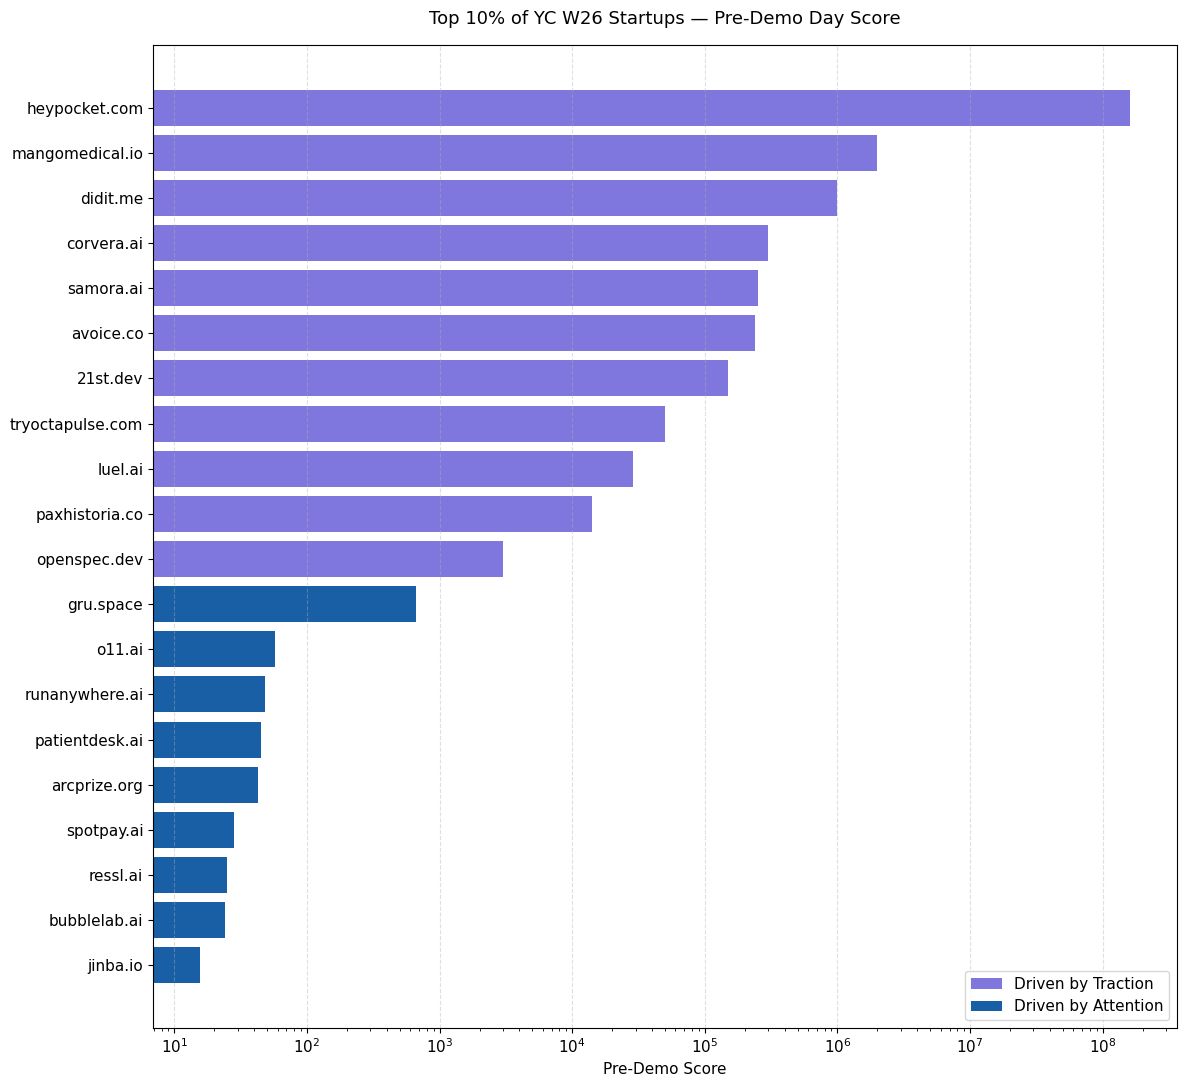

In [ ]:

from matplotlib.patches import Patch
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

fig, ax = plt.subplots(figsize=(12, len(df_top) * 0.45 + 2))

bar_colors = [
    COL_TRACTION if row['Velocity_Score'] >= row['mentions_score'] else COL_MENTIONS_DEMO
    for _, row in df_top[::-1].iterrows()
]

# Plot the RAW hybrid_score on a log scale
ax.barh(df_top['domain'][::-1], df_top['hybrid_score'][::-1], color=bar_colors)

# Legend
legend_elements = [
    Patch(facecolor=COL_TRACTION,      label='Driven by Traction'),
    Patch(facecolor=COL_MENTIONS_DEMO, label='Driven by Attention'),
]
ax.legend(handles=legend_elements, loc='lower right')

ax.set_xlabel('Pre-Demo Score')
ax.set_title('Top 10% of YC W26 Startups — Pre-Demo Day Score', fontsize=13, pad=15)

# === Log scale with clean 10^3, 10^4, ... labels ===
ax.set_xscale('log')
ax.xaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0]))                    # only powers of 10
ax.xaxis.set_major_formatter(LogFormatterSciNotation(labelOnlyBase=True))       # shows 10³, 10⁴ etc.

ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
df_vc=df
def compute_vc_score(row):
    weighted_metrics = {}

    for metric, weight in vc_weights.items():
        weighted_metrics[metric] = row.get(metric, 0) * weight

    return max(weighted_metrics.values())

df_vc['vc_score'] = df_vc.apply(compute_vc_score, axis=1)

In [ ]:

startup_to_domain = {
    'Pocket': 'heypocket.com',
    'Avoice': 'avoice.co',
    'Mango Medical': 'mangomedical.io',
    'OctaPulse': 'tryoctapulse.com',
    'Luel': 'luel.ai',
    'Pax Historia': 'paxhistoria.co',
    'Didit': 'didit.me',
    '21st': '21st.dev',
    'OpenSpec': 'openspec.dev',
    'Samora AI': 'samora.ai',
   'Corvera': 'corvera.ai'

}

df_vc['domain'] = df_vc['Startup'].map(startup_to_domain)

In [ ]:
df_domains=df
df_all = df_domains.merge(df_vc[['domain', 'vc_score']], on='domain', how='left')

In [ ]:
import pandas as pd
from io import StringIO

# Recreate the original Google mentions dataframe
lines_mentions = [line.split(": ") for line in raw_data.strip().split("\n")]
df_mentions_original = pd.DataFrame(lines_mentions, columns=["domain", "google_mentions"])
df_mentions_original["google_mentions"] = pd.to_numeric(df_mentions_original["google_mentions"])

# Now, merge this with df_all (which currently contains VC data and domains)
df_all = df_all.merge(df_mentions_original[['domain', 'google_mentions']], on='domain', how='left')

df_all['mentions_score'] = df_all['google_mentions'] * 0.05

In [ ]:
df_all['Score'] = df_all[['vc_score_x', 'mentions_score']].max(axis=1)

In [ ]:
df_all['Log_Score'] = np.log10(df_all['Score'].replace(0, 1))

In [ ]:

top_n = int(len(df_all) * 0.10)
df_top = df_all.sort_values(by='Score', ascending=False).head(top_n)

In [ ]:

vc_weights = {
    'arr':             1.00,
    'pilot_revenue':   0.50,
    'loi':             0.20,
    'active_users':    0.40,
    'activity_volume': 0.25,
    'signups':         0.15,
    'ecosystem_pull':  0.10,
    'google_mentions': 0.05,  # NEW
}

In [ ]:

def compute_vc_score(row):
    weighted_metrics = {}

    for metric, weight in vc_weights.items():
        weighted_metrics[metric] = row.get(metric, 0) * weight

    return max(weighted_metrics.values())

df['Score'] = df.apply(compute_vc_score, axis=1)

# Your existing log scaling (keep this)
df['Log_Score'] = np.log10(df['Score'].replace(0, 1)).round(2)

df_ranked = df.sort_values(by='Score', ascending=False).reset_index(drop=True)
df_ranked[['Startup', 'Score', 'Log_Score']]

,Startup,Score,Log_Score
0,Pocket,27000000.0,7.43
1,Mango Medical,2000000.0,6.30
2,Didit,1000000.0,6.00
3,Corvera,300000.0,5.48
4,Samora AI,250000.0,5.40
5,Avoice,240000.0,5.38
6,21st,150000.0,5.18
7,OctaPulse,50000.0,4.70
8,Luel,28500.0,4.45
9,Pax Historia,14000.0,4.15


In [ ]:

df['Score'] = df.apply(compute_vc_score, axis=1)

# Your existing log scaling (keep this)
df['Log_Score'] = np.log10(df['Score'].replace(0, 1)).round(2)

df_ranked = df.sort_values(by='Score', ascending=False).reset_index(drop=True)
df_ranked[['Startup', 'Score', 'Log_Score']]

,Startup,Score,Log_Score
0,Pocket,27000000.0,7.43
1,Mango Medical,2000000.0,6.30
2,Didit,1000000.0,6.00
3,Corvera,300000.0,5.48
4,Samora AI,250000.0,5.40
5,Avoice,240000.0,5.38
6,21st,150000.0,5.18
7,OctaPulse,50000.0,4.70
8,Luel,28500.0,4.45
9,Pax Historia,14000.0,4.15


Select top 10%

In [ ]:

top_10_pct = int(len(df) * 0.1)
df_top = df.sort_values(by='Score', ascending=False).head(top_10_pct)

#Baseline: top 10 % of Google Mentions on a similarly sized time window before YC W26 application deadline (August 17th to October 31st 2025, 67 days)

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

# 1. Load the raw data
raw_data = """
trycardinal.ai: 43
try.wideframe.com: 0
martini.film: 0
condor.energy: 0
resonate.audio: 0
shofo.ai: 3
wayco.ai: 60
unifold.io: 7
carrotlabs.ai: 27
aurorincad.com: 0
daivin.tech: 0
grazemate.com: 10
origami-robotics.com: 5
librarlabs.com: 1
therubric.ai: 0
zymbly.com: 0
ritivel.com: 2
usepolymorph.com: 2
pollinate.tech: 1
spotpay.ai: 271
voygr.tech: 0
mochacare.com: 0
tryvela.ai: 3
veriad.com: 0
talkingcomputers.ai: 0
copperlane.ai: 9
runcanary.ai: 1
usegrade.com: 0
silahq.com: 2
trymaven.com: 1
usemoda.ai: 0
thetokencompany.com: 0
beesafe.ai: 29
fed10.ai: 6
squid.energy: 0
usecrow.ai: 8
scoutout.ai: 47
bookoapp.com: 148
corelayer.com: 1
general.legal: 0
fort.cx: 10
getbalance.ai: 0
chasi.co: 10
tryremy.ai: 0
buildwithglue.com: 9
o11.ai: 450
doomersion.com: 3
sequencemkts.com: 0
dittobio.com: 66
servo7.com: 1
arzule.com: 0
voxelenergy.com: 0
polymathlabs.ai: 2
bubblelab.ai: 194
heypocket.com: 281
byteport.io: 0
constellationspace.ai: 1
mendral.com: 3
axionorbital.space: 189
oximy.com: 0
caretta.so: 0
samora.ai: 74
humanarchive.ai: 5
forum.market: 0
sitefire.ai: 6
tryrobby.com: 0
ressl.ai: 276
emdash.sh: 6
congruent.io: 0
usereframe.ai: 0
valence.trade: 8
approxima.ai: 0
traverse.so: 0
revion.inc: 1
maywoodai.com: 1
fenrock.ai: 0
endclose.com: 0
usechamber.io: 1
patientdesk.ai: 279
visiblsemi.com: 0
syntheticsciences.ai: 81
seeing-systems.com: 1
jinba.io: 46
usecardboard.com: 4
pranadoc.com: 4
rhizomeai.com: 5
paxhistoria.co: 4450
hex.co: 0
trylaurence.com: 1
terminaluse.com: 0
overshoot.ai: 47
caj.al: 0
proximitty.ai: 1
stilta.com: 2
unisson.ai: 2
incidentfox.ai: 1
compresr.ai: 6
opalitehealth.com: 0
confluence.sh: 72
mangomedical.io: 2
paysponge.com: 0
terranox.ai: 60
ventura.ai: 0
orthogonal.com: 34
perfectly.so: 0
getfern.ai: 0
sparkles.dev: 4
eigenpal.com: 1
usesalus.ai: 6
arcline-ai.com: 0
ramain.ai: 3
milliray.com: 0
beyondreachlabs.com: 1
tryoctapulse.com: 2
codewisp.ai: 4
ashr.io: 1
aemon.ai: 2
luel.ai: 124
schedulingwiz.com: 5
robodock.tech: 2
skillsync.wiki: 5
mousecat.ai: 1
zatanna.ai: 0
autositu.com: 9
verdexai.com: 2
cumuluslabs.io: 1
tepali.com: 0
palus.finance: 10
21st.dev: 1880
avoice.co: 0
kytentech.com: 1
zerosettle.io: 0
usecarson.com: 0
openspec.dev: 87
pirislabs.io: 3
celltype.com: 0
trainburt.com: 1
envariant.ai: 0
runcascade.com: 0
beaconhealth.ai: 0
strandai.com: 0
tryclam.com: 1
protent.ai: 3
cofia.ai: 1
getnoetic.ai: 0
legalos.ai: 62
sentrial.com: 1
10xscience.com: 218
rev1.so: 7
shortkit.dev: 0
tryasimov.ai: 3
lexius.ai: 3
axisanalysis.com: 0
sonarly.com: 1
docurahealth.com: 34
lance.live: 0
runanywhere.ai: 182
lucenthq.com: 4
rumacare.com: 2
klausai.com: 2
usekita.com: 2
syntropy.io: 8
onerobot.io: 0
didit.me: 2940
pantainsure.com: 3
payna.com: 1
origin.bio: 0
hlaboratories.com: 1
helloeos.ai: 1
valgo.ai: 42
arcprize.org: 784
corvera.ai: 5
fullseam.com: 0
catchbackcards.com: 150
mantisbiotech.com: 1
haladir.com: 2
claimglide.com: 1
inviscidai.com: 44
ndea.com: 51
crosslayerlabs.com: 0
voltairlabs.com: 4
vectorlegal.com: 0
generalastro.com: 0
oxus-ai.com: 0
runcaptain.com: 6
agenticfabriq.com: 2
travoai.com: 3
velum-labs.com: 3
alt-x.co: 3
buttoncomputer.com: 2
pollen.cx: 2
autumnai.com: 1
overdrive.health: 0
returnsignals.com: 0
gru.space: 4340
usebidflow.com: 0
menza.ai: 259
tryq2q.com: 2

"""

# 2. Parse into a DataFrame
lines = [line.split(": ") for line in raw_data.strip().split("\n")]
df = pd.DataFrame(lines, columns=["domain", "google_mentions"])
df["google_mentions"] = pd.to_numeric(df["google_mentions"])

# 3. Clean and sort (remove zeros for log-scale plotting)
df = df[df["google_mentions"] > 0]
df = df.sort_values(by="google_mentions", ascending=False).reset_index(drop=True)

print(f"Loaded {len(df)} active startup domains.")
df.head()

Loaded 130 active startup domains.


,domain,google_mentions
0,paxhistoria.co,4450
1,gru.space,4340
2,didit.me,2940
3,21st.dev,1880
4,arcprize.org,784


Total active domains: 130
Top 10% contains: 20 domains
These 20 domains represent 93.9% of all Google mentions in the dataset



,rank,domain,google_mentions,pct_of_total
0,1,paxhistoria.co,4450,23.8
1,2,gru.space,4340,23.2
2,3,didit.me,2940,15.7
3,4,21st.dev,1880,10.0
4,5,arcprize.org,784,4.2
5,6,o11.ai,450,2.4
6,7,heypocket.com,281,1.5
7,8,patientdesk.ai,279,1.5
8,9,ressl.ai,276,1.5
9,10,spotpay.ai,271,1.4


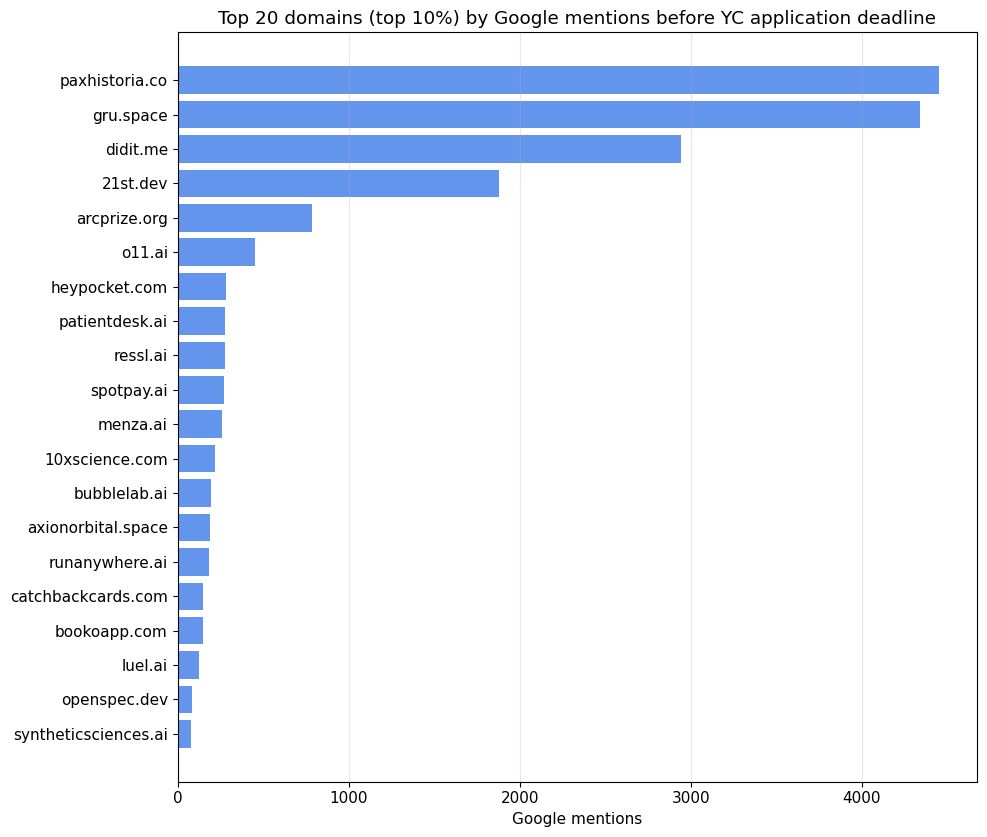

In [ ]:

# ───────────────────────────────────
#          Top 10% of domains by Google mentions
# ───────────────────────────────────

# Number of domains in top 10%
n_total = len(df)
n_top = 20 # User specified to take top 19 domains

# Take top 10%
top_10pct = df.head(n_top).copy()

# Add rank column (1-based)
top_10pct['rank'] = top_10pct.index + 1

# Optional: add percentage of total mentions
total_mentions = df['google_mentions'].sum()
top_10pct['pct_of_total'] = (top_10pct['google_mentions'] / total_mentions * 100).round(1)

print(f"Total active domains: {n_total}")
print(f"Top 10% contains: {n_top} domains")
print(f"These {n_top} domains represent {top_10pct['google_mentions'].sum() / total_mentions * 100:.1f}% "
      f"of all Google mentions in the dataset\n")

# Show nicely formatted table
display(top_10pct[['rank', 'domain', 'google_mentions', 'pct_of_total']])

# ── Optional quick bar chart of top 10% ──────────
if n_top <= 40:  # avoid horrible plot when there are too many
    plt.figure(figsize=(10, len(top_10pct) * 0.35 + 1.5))
    plt.barh(top_10pct['domain'], top_10pct['google_mentions'], color='cornflowerblue')
    plt.gca().invert_yaxis()
    plt.title(f'Top {n_top} domains (top 10%) by Google mentions before YC application deadline')
    plt.xlabel('Google mentions')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\u2192 Too many domains in top 10% to plot meaningfully.")

In [ ]:
k = n_top  # 20

# Ground truth: top by hybrid score
top_hybrid = df_hybrid_sorted.nlargest(k, 'log_hybrid_score')

# Baseline: top by Google mentions (pre-deadline)
top_baseline = df.nlargest(k, 'google_mentions')

# Convert to sets of domains
set_hybrid = set(top_hybrid['domain'])
set_baseline = set(top_baseline['domain'])

# Intersection = correctly predicted by baseline
correct = set_hybrid & set_baseline

precision_baseline = len(correct) / k

print(f"Correct predictions (baseline ∩ hybrid): {len(correct)}/{k}")
print(f"Precision@Top{k} (baseline): {precision_baseline:.2%}")

Correct predictions (baseline ∩ hybrid): 14/20
Precision@Top20 (baseline): 70.00%


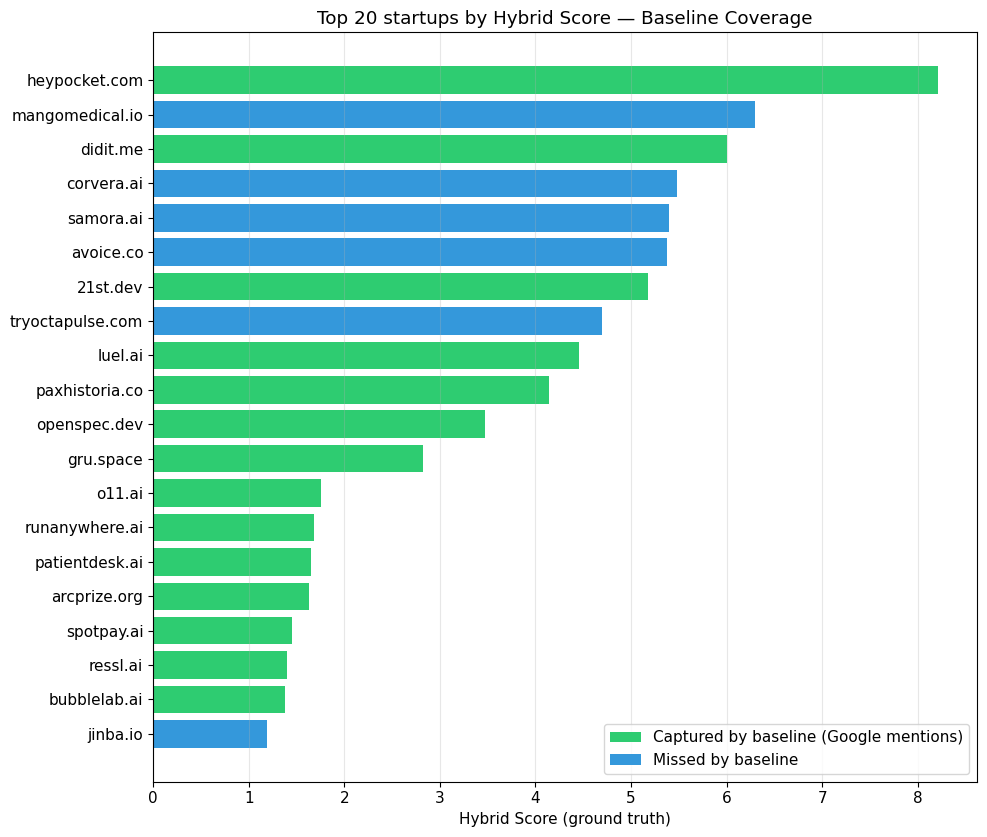

In [ ]:

# Ground truth top (for plotting)
plot_df = top_hybrid.iloc[::-1].copy()

# Color: is it captured by baseline?
bar_colors = [
    '#2ecc71' if domain in set_baseline else '#3498db'
    for domain in plot_df['domain']
]

plt.figure(figsize=(10, len(plot_df) * 0.35 + 1.5))
plt.barh(plot_df['domain'], plot_df['log_hybrid_score'], color=bar_colors)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Captured by baseline (Google mentions)'),
    Patch(facecolor='#3498db', label='Missed by baseline'),
]
plt.legend(handles=legend_elements, loc='lower right')

plt.xlabel('Hybrid Score (ground truth)')
plt.title(f'Top {k} startups by Hybrid Score — Baseline Coverage')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

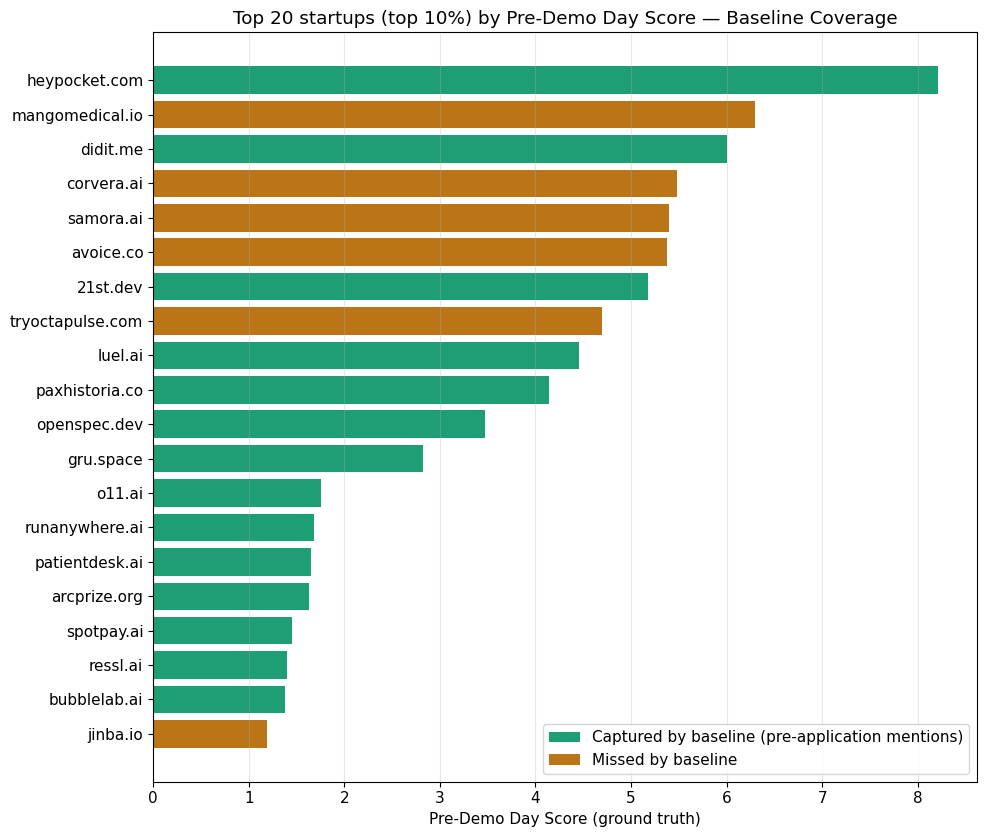

In [ ]:

from matplotlib.patches import Patch

plot_df = top_hybrid.iloc[::-1].copy()

bar_colors = [
    COL_TOP if domain in set_baseline else COL_MISSED
    for domain in plot_df['domain']
]

plt.figure(figsize=(10, len(plot_df) * 0.35 + 1.5))
plt.barh(plot_df['domain'], plot_df['log_hybrid_score'], color=bar_colors)

legend_elements = [
    Patch(facecolor=COL_TOP,    label='Captured by baseline (pre-application mentions)'),
    Patch(facecolor=COL_MISSED, label='Missed by baseline'),
]
plt.legend(handles=legend_elements, loc='lower right')

plt.xlabel('Pre-Demo Day Score (ground truth)')
plt.title(f'Top {k} startups (top 10%) by Pre-Demo Day Score — Baseline Coverage')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

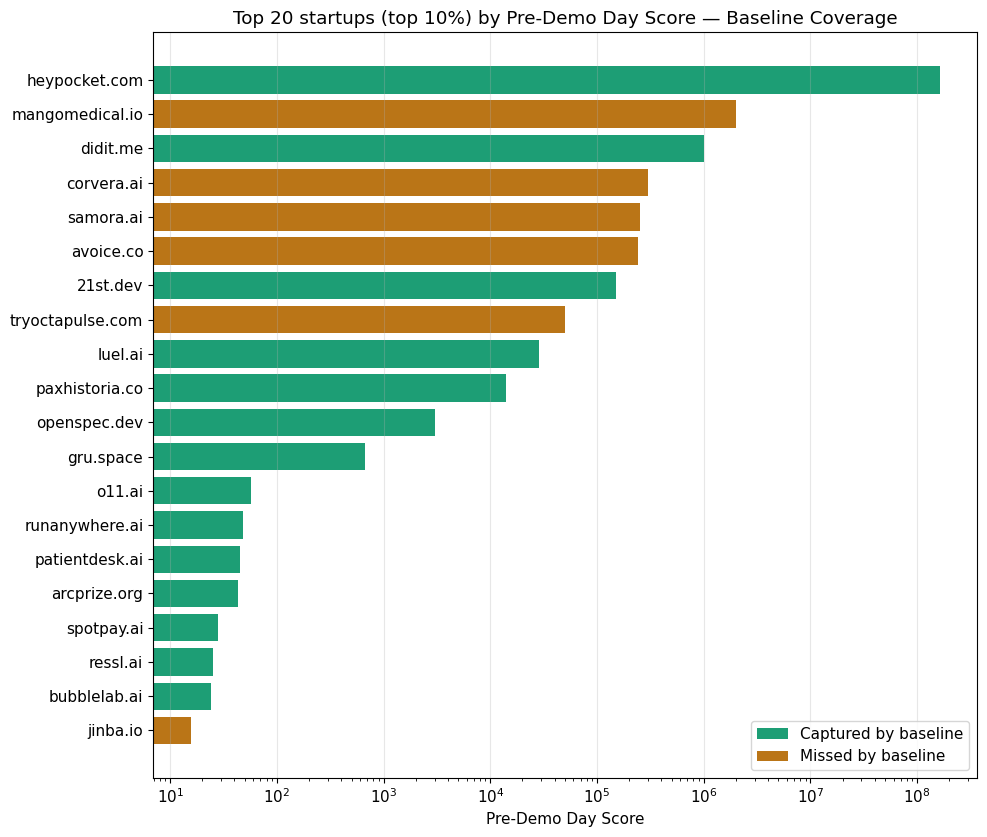

In [ ]:

from matplotlib.patches import Patch
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

plot_df = top_hybrid.iloc[::-1].copy()

bar_colors = [
    COL_TOP if domain in set_baseline else COL_MISSED
    for domain in plot_df['domain']
]

plt.figure(figsize=(10, len(plot_df) * 0.35 + 1.5))
plt.barh(plot_df['domain'], plot_df['hybrid_score'], color=bar_colors)   # ← raw score

legend_elements = [
    Patch(facecolor=COL_TOP,    label='Captured by baseline'),
    Patch(facecolor=COL_MISSED, label='Missed by baseline'),
]
plt.legend(handles=legend_elements, loc='lower right')

plt.xlabel('Pre-Demo Day Score')
plt.title(f'Top {k} startups (top 10%) by Pre-Demo Day Score — Baseline Coverage')

# === Log scale with clean 10^3, 10^4 labels ===
plt.xscale('log')
plt.gca().xaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0]))
plt.gca().xaxis.set_major_formatter(LogFormatterSciNotation(labelOnlyBase=True))

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

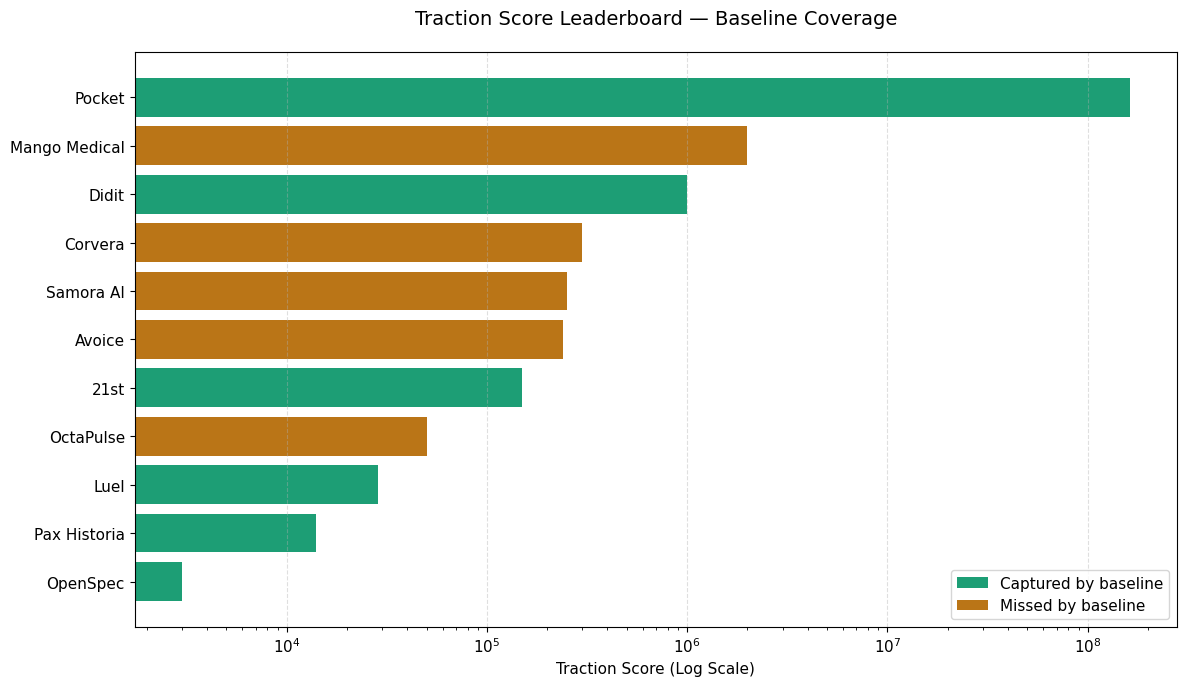

In [ ]:

from matplotlib.patches import Patch
import matplotlib.pyplot as plt

# Ensure domain mapping exists
df_velocity_ranked['domain'] = df_velocity_ranked['Startup'].map(startup_to_domain)

plt.figure(figsize=(12, 7))

# Color logic: baseline capture vs miss
bar_colors = [
    COL_TOP if domain in set_baseline else COL_MISSED
    for domain in df_velocity_ranked['domain'][::-1]
]

# Plot
plt.barh(
    df_velocity_ranked['Startup'][::-1],
    df_velocity_ranked['Velocity_Score'][::-1],
    color=bar_colors
)

# Legend (consistent with rest of notebook)
legend_elements = [
    Patch(facecolor=COL_TOP,    label='Captured by baseline'),
    Patch(facecolor=COL_MISSED, label='Missed by baseline'),
]
plt.legend(handles=legend_elements, loc='lower right')

# Styling
plt.xlabel('Traction Score (Log Scale)')
plt.title('Traction Score Leaderboard — Baseline Coverage', fontsize=14, pad=20)
plt.xscale('log')
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()